# Welding Defect Detection & Classification
**Task:** detect weld regions in an image and classify each as `Bad Weld`, `Good Weld` or `Defect`, with a safety-first decision layer (low false-negative rate, human review for uncertain cases).

### What this notebook does
| # | Requirement | Where |
|---|---|---|
| 1 | Count chart; drop **train** images with > 6 boxes | §3, §4 |
| 2 | Drop boxes with area < threshold | §3, §4 |
| 3 | Losses/metrics on val & test: overall, by box-count bucket (1, 2, 3-6, 7-10, 10+), by area (above/below thr), with and without conditions 1+2 | §9 |
| 4 | Focal loss if classes are imbalanced | §5 (rule-based), §6, §7 |
| 5 | Method A: YOLO 3-class **vs** Method B: YOLO weld-detector + CNN classifier | §6, §7, §11 |
| 6 | Confidence -> learned thresholds -> uncertain images go to a human | §10 |
| 7 | Minimise FN (bad/defect predicted as good) | §10 (recall-constrained threshold) |
| 8 | CSV log of losses for every model, with metadata | §4b, `experiment_log.csv` |
| 9 | Calibration when needed (ECE-triggered; temperature / Platt / isotonic) | §10 |

### Key definitions (read these, they matter)
* **"Not-OK" classes** = `Bad Weld` (0) and `Defect` (2). **OK** = `Good Weld` (1).
* **FN (the thing we minimise)** = an image that *truly* contains a Bad Weld/Defect but the system auto-**PASSES** it. A missed detection (no box at all) also counts as a pass, so it is an FN too.
* **Image-level score** `s_bad` = calibrated confidence that the image contains a Not-OK weld. It drives the 3-way decision **PASS / REJECT / REVIEW (human)**.
* **Box-level loss** for YOLO is the Ultralytics loss (box + cls + dfl), always re-computed with *plain BCE* at evaluation time so focal-trained and BCE-trained models are comparable.

### Running it
Designed for a GPU (Colab/Kaggle T4 is fine, ~30-40 min end to end). Set `WELD_QUICK=1` for a tiny CPU smoke test of the whole pipeline (numbers are then meaningless).

In [1]:
# Colab / Kaggle: uncomment. (Pinned because the loss-patching in section 5 touches Ultralytics internals.)
!pip -q install "ultralytics==8.4.156" scikit-learn seaborn scipy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.7 MB/s eta 0:00:00


In [2]:
import os, sys, json, math, time, random, shutil, glob, re, pickle, warnings, platform, datetime as dt
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch, torch.nn as nn, torch.nn.functional as F
import ultralytics
from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11})

QUICK = os.environ.get("WELD_QUICK", "0") == "1"   # tiny smoke-test mode
SEED = 42
def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_all()
DEVICE = 0 if torch.cuda.is_available() else "cpu"           # for ultralytics
TDEV = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["Bad Weld", "Good Weld", "Defect"]
BAD_IDS = (0, 2)                                              # "Not-OK" classes
CLASS_COLORS = {0: "#e15759", 1: "#59a14f", 2: "#f28e2b"}
SPLITS = ["train", "valid", "test"]

# ---- analysis conditions (requirements 1 & 2) and decision targets -------------------------------------
CFG = dict(
    MAX_BOXES_TRAIN=6,               # cond 1: train images with MORE than this many boxes are removed
    AREA_THR=0.004,                  # cond 2: min normalised box area (w*h). 0.004 ~ 40x40 px on a 640 px image
    SMALL_BOX_POLICY="drop_box",     # "drop_box": delete the tiny boxes | "drop_image": delete images that contain one
    COUNT_BINS=[0, 1, 2, 6, 10, 10**6], COUNT_LABELS=["1", "2", "3-6", "7-10", "10+"],
    IMBALANCE_RATIO_FOR_FOCAL=1.5,   # max/min class-box ratio above which focal loss is used
    YOLO_FOCAL_GAMMA=1.5, CNN_FOCAL_GAMMA=2.0,
    FN_TARGET=0.02,                  # max tolerated miss-rate on Not-OK images (learned on val)
    REJECT_PREC_TARGET=0.90,         # precision required before auto-REJECT (otherwise -> human)
    ECE_TOL=0.05,                    # calibrate only if val ECE exceeds this
    N_BOOT=50 if QUICK else 500,
)
HP = dict(
    yolo_weights="yolo11n.pt" if QUICK else "yolo11s.pt",
    imgsz=320 if QUICK else 640, epochs=int(os.environ.get("WELD_EPOCHS", 2 if QUICK else 60)), batch=8 if QUICK else 16,
    patience=15, workers=0 if QUICK else 2,
    cnn_size=64 if QUICK else 128, cnn_epochs=int(os.environ.get("WELD_CNN_EPOCHS", 2 if QUICK else 25)), cnn_bs=32 if QUICK else 64,
    cnn_lr=3e-4, cnn_patience=8,
)
WORK = Path(os.environ.get("WELD_WORK", "weld_work_quick" if QUICK else "weld_work")); WORK.mkdir(exist_ok=True, parents=True)
LOG_PATH = WORK / "experiment_log.csv"
print(f"QUICK={QUICK} | device={TDEV} | torch {torch.__version__} | ultralytics {ultralytics.__version__}")
print("CFG:", {k: v for k, v in CFG.items() if k not in ("COUNT_BINS",)})

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
QUICK=False | device=cuda:0 | torch 2.11.0+cu128 | ultralytics 8.4.156
CFG: {'MAX_BOXES_TRAIN': 6, 'AREA_THR': 0.004, 'SMALL_BOX_POLICY': 'drop_box', 'COUNT_LABELS': ['1', '2', '3-6', '7-10', '10+'], 'IMBALANCE_RATIO_FOR_FOCAL': 1.5, 'YOLO_FOCAL_GAMMA': 1.5, 'CNN_FOCAL_GAMMA': 2.0, 'FN_TARGET': 0.02, 'REJECT_PREC_TARGET': 0.9, 'ECE_TOL': 0.05, 'N_BOOT': 500}


## 1. Locate & parse the dataset
The Kaggle export is in YOLO format (`class xc yc w h`, normalised). Every image is 640x640.

In [3]:
def find_dataset_root():
    cands = [os.environ.get("WELD_DATA_ROOT"), "The Welding Defect Dataset", "/content/The Welding Defect Dataset",
             "/kaggle/input/welding-defect-object-detection/The Welding Defect Dataset"]
    for c in cands:
        if c and (Path(c) / "data.yaml").exists(): return Path(c)
    for g in glob.glob("/kaggle/input/**/data.yaml", recursive=True) + glob.glob("/content/**/data.yaml", recursive=True):
        return Path(g).parent
    zips = [os.environ.get("WELD_ZIP"), "The_Welding_Defect_Dataset.zip", "/content/The_Welding_Defect_Dataset.zip",
            "/mnt/user-data/uploads/The_Welding_Defect_Dataset.zip"]
    for z in zips:
        if z and Path(z).exists():
            import zipfile; zipfile.ZipFile(z).extractall(WORK / "raw")
            return next((WORK / "raw").rglob("data.yaml")).parent
    try:   # last resort: Kaggle download (needs kagglehub + credentials)
        import kagglehub
        p = kagglehub.dataset_download("sukmaadhiwijaya/welding-defect-object-detection")
        return next(Path(p).rglob("data.yaml")).parent
    except Exception as e:
        raise FileNotFoundError("Dataset not found. Put the unzipped folder next to the notebook, set WELD_DATA_ROOT, or WELD_ZIP.") from e

ROOT = find_dataset_root()
print("dataset root:", ROOT)

def read_all_labels(root):
    rows = []
    for sp in SPLITS:
        for f in sorted((root / sp / "labels").glob("*.txt")):
            for ln in f.read_text().splitlines():
                p = ln.split()
                if len(p) >= 5: rows.append((sp, f.stem, int(p[0]), *map(float, p[1:5])))
    d = pd.DataFrame(rows, columns=["split", "stem", "cls", "xc", "yc", "w", "h"])
    d["area"] = d.w * d.h
    d["src"] = d.stem.str.replace(r"\.rf\.[0-9a-f]+$", "", regex=True)          # original image before Roboflow augmentation
    d["n_raw"] = d.groupby(["split", "stem"]).cls.transform("size")            # boxes in the image (raw)
    d["bucket"] = pd.cut(d.n_raw, CFG["COUNT_BINS"], labels=CFG["COUNT_LABELS"])
    d["small"] = d.area < CFG["AREA_THR"]
    return d

df_all = read_all_labels(ROOT)
IMG_PATH = {}
for sp in SPLITS:
    for f in (ROOT / sp / "images").iterdir(): IMG_PATH[(sp, f.stem)] = str(f)
assert all((r.split, r.stem) in IMG_PATH for r in df_all.drop_duplicates(["split", "stem"]).itertuples()), "label without image"
df_all["name"] = df_all.cls.map(dict(enumerate(CLASS_NAMES)))
print(df_all.groupby(["split", "name"]).size().unstack().assign(images=df_all.groupby("split").stem.nunique()))

Using Colab cache for faster access to the 'welding-defect-object-detection' dataset.
dataset root: /kaggle/input/welding-defect-object-detection/The Welding Defect Dataset/The Welding Defect Dataset
name   Bad Weld  Defect  Good Weld  images
split                                     
test         67      66         76      74
train       736    1298       1111     839
valid       127     193        253     176


## 2. Data-quality checks (things that affect how far to trust the numbers)

In [4]:
# (a) Roboflow augmentation copies: how many files per original image?
copies = df_all.drop_duplicates(["split", "stem"]).groupby(["split", "src"]).size().rename("copies").reset_index()
print("files per original image:\n", copies.groupby("split").copies.describe()[["count", "mean", "max"]])
# (b) leakage between splits by original-image name
srcs = {sp: set(df_all[df_all.split == sp].src) for sp in SPLITS}
LEAK_SRC = srcs["train"] & (srcs["valid"] | srcs["test"])
print("\noriginal images shared between train and val/test (removed from train):", len(LEAK_SRC), list(LEAK_SRC)[:3])
# (c) frames of the same *video* land in several splits -> near-duplicate frames -> optimistic scores
vid = (df_all.assign(video=df_all.stem.str.extract(r"(SampleV\d_\d)")[0]).dropna(subset=["video"])
       .groupby(["video", "split"]).stem.nunique().unstack(fill_value=0))
print("\nvideo-derived frames per split (same video in several splits):\n", vid)
# (d) image-level prevalence of Not-OK
img_all = df_all.groupby(["split", "stem"]).agg(n=("cls", "size"), y_bad=("cls", lambda c: int(np.isin(c, BAD_IDS).any()))).reset_index()
print("\nimages containing a Bad Weld/Defect:\n", img_all.groupby("split").y_bad.agg(["sum", "size", "mean"]).round(3))

files per original image:
        count     mean  max
split                     
test    74.0  1.00000  1.0
train  542.0  1.54797  6.0
valid  176.0  1.00000  1.0

original images shared between train and val/test (removed from train): 1 ['Screenshot-2022-12-05-223445_jpeg_jpg']

video-derived frames per split (same video in several splits):
 split       test  train  valid
video                         
SampleV1_1     2     95     11
SampleV1_2     1     57      9
SampleV2_1     5    139     21
SampleV2_2     8    133     26
SampleV3_1     4     55     11
SampleV3_2     1     37      3

images containing a Bad Weld/Defect:
        sum  size   mean
split                  
test    45    74  0.608
train  630   839  0.751
valid  104   176  0.591


## 3. EDA -> count chart (condition 1) and area analysis (condition 2)

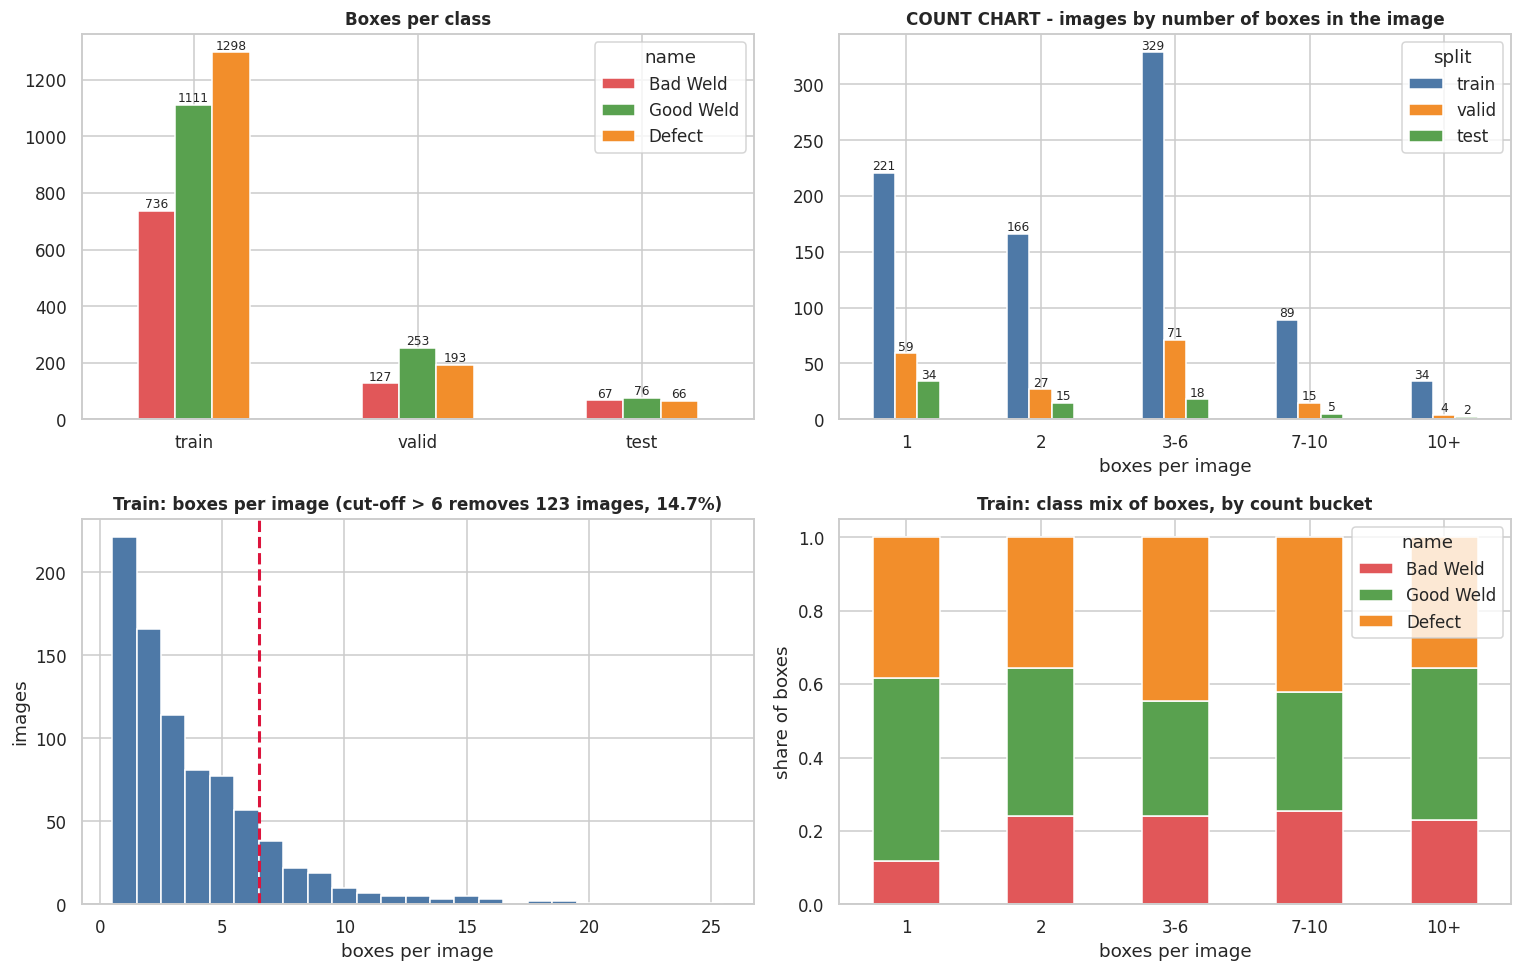

bucket    1    2  3-6  7-10  10+
split                           
train   221  166  329    89   34
valid    59   27   71    15    4
test     34   15   18     5    2


In [5]:
cnt_tab = (df_all.drop_duplicates(["split", "stem"]).groupby(["split", "bucket"]).size().unstack(fill_value=0)
           .reindex(SPLITS)[CFG["COUNT_LABELS"]])
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# (a) class distribution per split
cls_tab = df_all.groupby(["split", "name"]).size().unstack().reindex(SPLITS)[CLASS_NAMES]
cls_tab.plot.bar(ax=ax[0, 0], color=[CLASS_COLORS[i] for i in range(3)], rot=0)
ax[0, 0].set_title("Boxes per class"); ax[0, 0].set_xlabel("")
for c in ax[0, 0].containers: ax[0, 0].bar_label(c, fontsize=8)

# (b) THE COUNT CHART: images per boxes-per-image bucket
cnt_tab.T.plot.bar(ax=ax[0, 1], rot=0, color=["#4e79a7", "#f28e2b", "#59a14f"])
ax[0, 1].set_title("COUNT CHART - images by number of boxes in the image"); ax[0, 1].set_xlabel("boxes per image")
for c in ax[0, 1].containers: ax[0, 1].bar_label(c, fontsize=8)

# (c) exact histogram (train) with the cut-off
tr_n = df_all[df_all.split == "train"].drop_duplicates("stem").n_raw
ax[1, 0].hist(tr_n, bins=np.arange(0.5, tr_n.max() + 1.5), color="#4e79a7", edgecolor="w")
ax[1, 0].axvline(CFG["MAX_BOXES_TRAIN"] + 0.5, color="crimson", ls="--", lw=2)
n_drop = int((tr_n > CFG["MAX_BOXES_TRAIN"]).sum())
ax[1, 0].set_title(f"Train: boxes per image (cut-off > {CFG['MAX_BOXES_TRAIN']} removes {n_drop} images, {n_drop/len(tr_n):.1%})")
ax[1, 0].set_xlabel("boxes per image"); ax[1, 0].set_ylabel("images")

# (d) class mix by count bucket (train)
mix = (df_all[df_all.split == "train"].groupby(["bucket", "name"]).size().unstack(fill_value=0)[CLASS_NAMES])
(mix.div(mix.sum(1), axis=0)).plot.bar(stacked=True, ax=ax[1, 1], rot=0, color=[CLASS_COLORS[i] for i in range(3)])
ax[1, 1].set_title("Train: class mix of boxes, by count bucket"); ax[1, 1].set_ylabel("share of boxes"); ax[1, 1].set_xlabel("boxes per image")
plt.tight_layout(); plt.show()
print(cnt_tab)

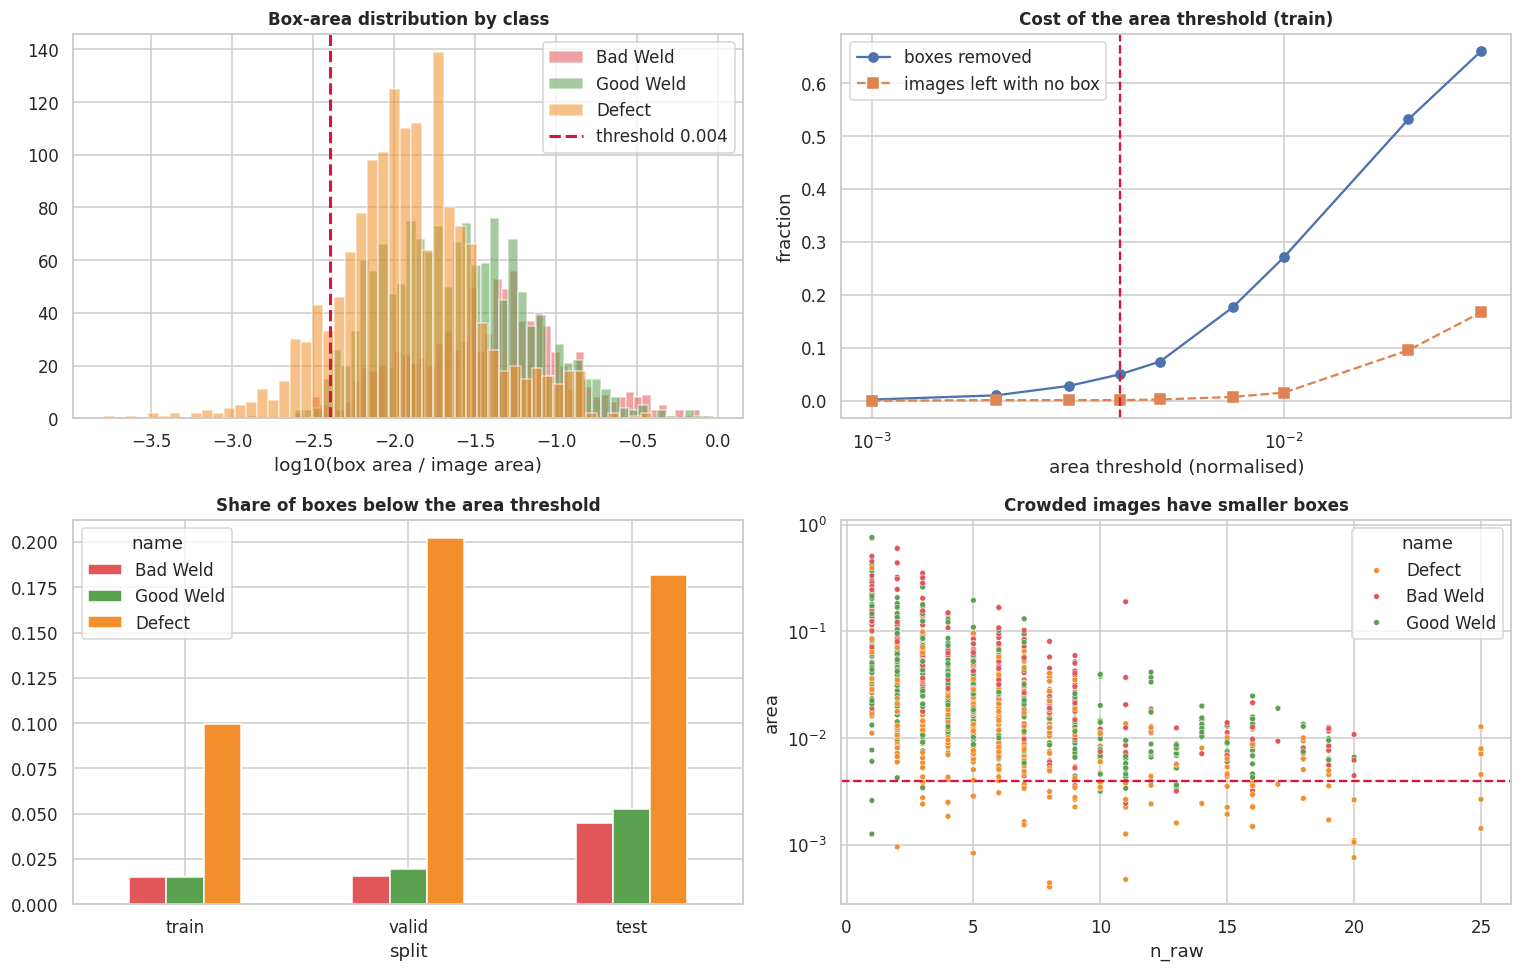

In [6]:
# Area analysis --------------------------------------------------------------------------------------------
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
for c in range(3):
    ax[0, 0].hist(np.log10(df_all[df_all.cls == c].area), bins=50, alpha=.55, color=CLASS_COLORS[c], label=CLASS_NAMES[c])
ax[0, 0].axvline(np.log10(CFG["AREA_THR"]), color="crimson", ls="--", lw=2, label=f"threshold {CFG['AREA_THR']}")
ax[0, 0].set_xlabel("log10(box area / image area)"); ax[0, 0].set_title("Box-area distribution by class"); ax[0, 0].legend()

thr_grid = np.array([0.001, 0.002, 0.003, 0.004, 0.005, 0.0075, 0.01, 0.02, 0.03])
tr = df_all[df_all.split == "train"]
frac_boxes = [(tr.area < t).mean() for t in thr_grid]
frac_imgs_empty = [(tr.assign(k=tr.area >= t).groupby("stem").k.any() == False).mean() for t in thr_grid]
ax[0, 1].plot(thr_grid, frac_boxes, "o-", label="boxes removed"); ax[0, 1].plot(thr_grid, frac_imgs_empty, "s--", label="images left with no box")
ax[0, 1].axvline(CFG["AREA_THR"], color="crimson", ls="--"); ax[0, 1].set_xscale("log"); ax[0, 1].legend()
ax[0, 1].set_title("Cost of the area threshold (train)"); ax[0, 1].set_xlabel("area threshold (normalised)"); ax[0, 1].set_ylabel("fraction")

sm = df_all.groupby(["split", "name"]).small.mean().unstack()[CLASS_NAMES].reindex(SPLITS)
sm.plot.bar(ax=ax[1, 0], rot=0, color=[CLASS_COLORS[i] for i in range(3)]); ax[1, 0].set_title("Share of boxes below the area threshold")
sns.scatterplot(data=df_all.sample(min(1500, len(df_all)), random_state=0), x="n_raw", y="area", hue="name", palette=dict(zip(CLASS_NAMES, CLASS_COLORS.values())), s=14, ax=ax[1, 1])
ax[1, 1].set_yscale("log"); ax[1, 1].axhline(CFG["AREA_THR"], color="crimson", ls="--"); ax[1, 1].set_title("Crowded images have smaller boxes")
plt.tight_layout(); plt.show()

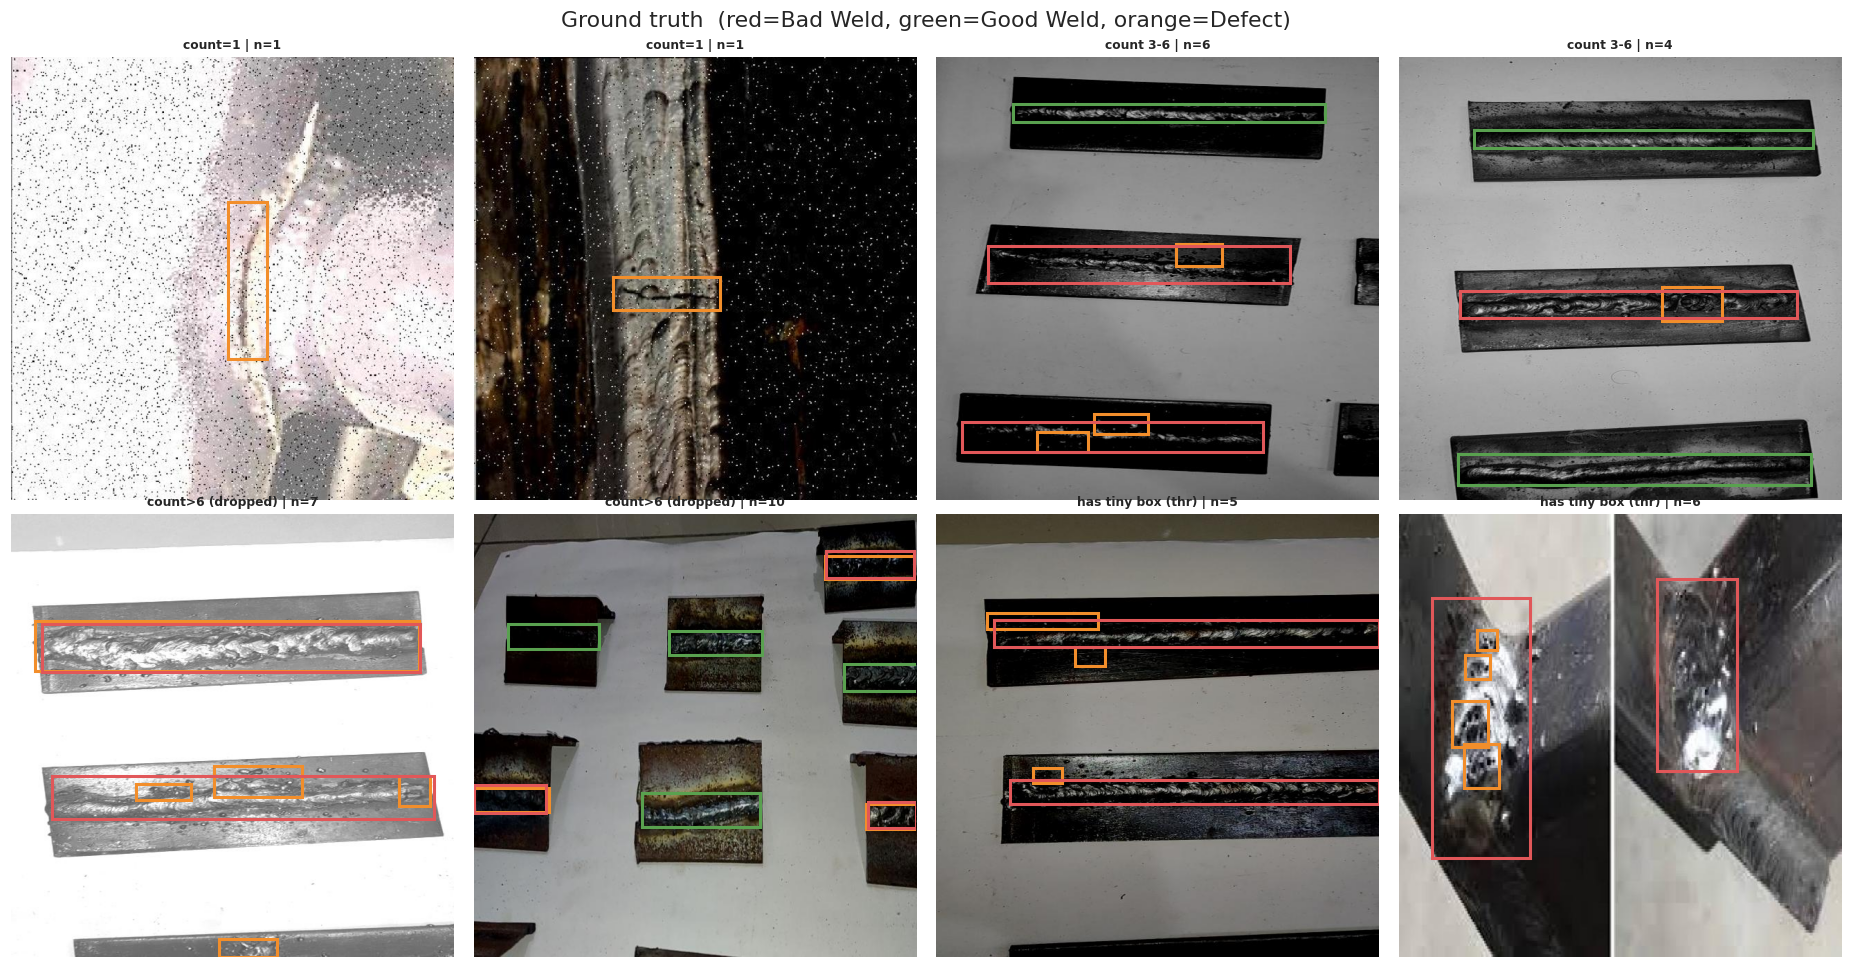

In [7]:
def draw_boxes(ax, img, boxes_xyxy_n, cls, title="", texts=None, lw=2):
    ax.imshow(img); ax.axis("off"); h, w = img.shape[:2]
    for i, (b, c) in enumerate(zip(boxes_xyxy_n, cls)):
        x1, y1, x2, y2 = b * [w, h, w, h]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=CLASS_COLORS[int(c)], lw=lw))
        if texts is not None: ax.text(x1, max(y1 - 3, 8), texts[i], color="w", fontsize=7, bbox=dict(fc=CLASS_COLORS[int(c)], ec="none", pad=1))
    ax.set_title(title, fontsize=8)

def read_rgb(path): return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
def xywh2xyxy(g): return np.stack([g.xc - g.w / 2, g.yc - g.h / 2, g.xc + g.w / 2, g.yc + g.h / 2], 1).clip(0, 1)

rng = np.random.RandomState(1)
tr_imgs = df_all[df_all.split == "train"]
picks = (list(rng.choice(tr_imgs[tr_imgs.n_raw == 1].stem.unique(), 2)) + list(rng.choice(tr_imgs[tr_imgs.n_raw.between(3, 6)].stem.unique(), 2)) +
         list(rng.choice(tr_imgs[tr_imgs.n_raw > 6].stem.unique(), 2)) + list(rng.choice(tr_imgs[tr_imgs.small].stem.unique(), 2)))
tags = ["count=1"] * 2 + ["count 3-6"] * 2 + ["count>6 (dropped)"] * 2 + ["has tiny box (thr)"] * 2
fig, axs = plt.subplots(2, 4, figsize=(17, 9))
for a, st, tg in zip(axs.ravel(), picks, tags):
    g = tr_imgs[tr_imgs.stem == st]
    draw_boxes(a, read_rgb(IMG_PATH[("train", st)]), xywh2xyxy(g), g.cls.values, f"{tg} | n={len(g)}")
plt.suptitle("Ground truth  (red=Bad Weld, green=Good Weld, orange=Defect)"); plt.tight_layout(); plt.show()

## 4. Apply conditions 1 & 2
* **Cond 1** - remove *train* images with more than `MAX_BOXES_TRAIN` boxes (count uses the raw number of boxes).
* **Cond 2** - remove boxes whose normalised area `w*h` < `AREA_THR` (images left with no box disappear).
  *Caveat:* deleting a real (tiny) weld's label teaches the model that region is background. It's the requested policy, and the effect is exactly what §9 measures (below-threshold slices); `SMALL_BOX_POLICY="drop_image"` is the alternative.

The same conditions can be applied to val/test to create a **"filtered" evaluation** (predictions below the area threshold are ignored there too, so correct tiny detections aren't punished as false positives). Every model is evaluated on **both** the raw and the filtered val/test sets.

            images   boxes  Bad Weld  Good Weld  Defect  imbalance_ratio
raw  train   838.0  3120.0     736.0     1111.0  1273.0             1.73
     valid   176.0   573.0     127.0      253.0   193.0             1.99
     test     74.0   209.0      67.0       76.0    66.0             1.15
filt train   715.0  1918.0     442.0      677.0   799.0             1.81
     valid   156.0   377.0      89.0      168.0   120.0             1.89
     test     66.0   133.0      42.0       55.0    36.0             1.53

train: cond1 removed 122 images | cond2 removed 28 boxes | images left: 715 / 838


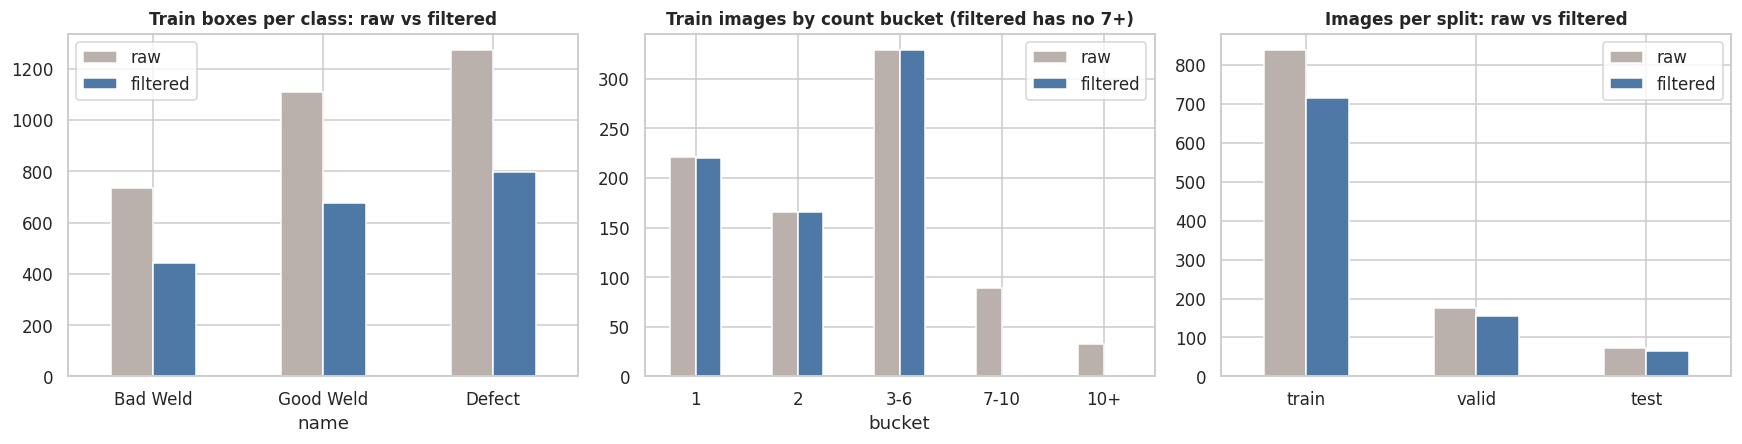

In [8]:
def apply_conditions(d, count=True, area=True):
    if count: d = d[d.n_raw <= CFG["MAX_BOXES_TRAIN"]]
    if area:
        if CFG["SMALL_BOX_POLICY"] == "drop_box": d = d[~d.small]
        else: d = d[~d.stem.isin(d.loc[d.small, "stem"].unique())]
    return d

# --- QUICK mode: work on a small random subset (the EDA above always uses the full data) ----------------
def subsample(d, n_by_split, seed=SEED):
    keep = []
    for sp, n in n_by_split.items():
        st = d[d.split == sp].stem.drop_duplicates().sample(frac=1, random_state=seed).tolist()[:n]; keep += st
    return d[d.stem.isin(set(keep))]
dfw = subsample(df_all, {"train": 90, "valid": 36, "test": 30}) if QUICK else df_all.copy()
dfw = dfw[~((dfw.split == "train") & dfw.src.isin(LEAK_SRC))]           # hygiene: drop train images whose original is in val/test

TABLES = {  # variant -> split -> box table (index = global row id)
    "raw":  {sp: dfw[dfw.split == sp] for sp in SPLITS},
    "filt": {"train": apply_conditions(dfw[dfw.split == "train"]),
             "valid": apply_conditions(dfw[dfw.split == "valid"]),
             "test":  apply_conditions(dfw[dfw.split == "test"])},
}
def summ(t):
    c = t.groupby("cls").size().reindex(range(3), fill_value=0)
    return dict(images=t.stem.nunique(), boxes=len(t), **{CLASS_NAMES[i]: int(c[i]) for i in range(3)}, imbalance_ratio=round(c.max() / max(c.min(), 1), 2))
summary = pd.DataFrame({(v, sp): summ(TABLES[v][sp]) for v in TABLES for sp in SPLITS}).T
print(summary)

tr0, tr1 = dfw[dfw.split == "train"], TABLES["filt"]["train"]
removed_c1 = tr0[tr0.n_raw > CFG["MAX_BOXES_TRAIN"]].stem.nunique()
removed_c2 = int(tr0[tr0.n_raw <= CFG["MAX_BOXES_TRAIN"]].small.sum())
print(f"\ntrain: cond1 removed {removed_c1} images | cond2 removed {removed_c2} boxes | images left: {tr1.stem.nunique()} / {tr0.stem.nunique()}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
pd.DataFrame({"raw": tr0.groupby("name").size(), "filtered": tr1.groupby("name").size()}).reindex(CLASS_NAMES).plot.bar(ax=ax[0], rot=0, color=["#bab0ac", "#4e79a7"])
ax[0].set_title("Train boxes per class: raw vs filtered")
pd.DataFrame({"raw": tr0.drop_duplicates("stem").bucket.value_counts(), "filtered": tr1.drop_duplicates("stem").bucket.value_counts()}).reindex(CFG["COUNT_LABELS"]).fillna(0).plot.bar(ax=ax[1], rot=0, color=["#bab0ac", "#4e79a7"])
ax[1].set_title("Train images by count bucket (filtered has no 7+)")
pd.DataFrame({sp: {"raw": len(TABLES["raw"][sp].stem.unique()), "filtered": len(TABLES["filt"][sp].stem.unique())} for sp in SPLITS}).T.plot.bar(ax=ax[2], rot=0, color=["#bab0ac", "#4e79a7"])
ax[2].set_title("Images per split: raw vs filtered"); plt.tight_layout(); plt.show()

## 5. Class imbalance -> focal loss decision
Rule: if `max(class boxes) / min(class boxes)` in the **raw** train set exceeds `IMBALANCE_RATIO_FOR_FOCAL`, focal loss is used - for *both* variants and *both* methods, so the raw-vs-filtered comparison isn't confounded by the loss choice.
YOLO: focal modulation `(1-p_t)^gamma` on the class BCE + sqrt-inverse-frequency class weights. CNN: focal CE with the same weights. (Evaluation always reports plain BCE/CE.)

In [9]:
imb_raw = summ(TABLES["raw"]["train"])["imbalance_ratio"]; imb_filt = summ(TABLES["filt"]["train"])["imbalance_ratio"]
USE_FOCAL = imb_raw > CFG["IMBALANCE_RATIO_FOR_FOCAL"]
print(f"imbalance ratio  raw={imb_raw}  filtered={imb_filt}  threshold={CFG['IMBALANCE_RATIO_FOR_FOCAL']}  ->  USE_FOCAL={USE_FOCAL}")
def class_weights(train_tbl):
    c = train_tbl.groupby("cls").size().reindex(range(3), fill_value=1).values.astype(float)
    w = 1 / np.sqrt(c); return (w / w.mean()).astype(np.float32)          # sqrt-inverse frequency, mean 1
print("class weights raw:", class_weights(TABLES["raw"]["train"]).round(2), "| filtered:", class_weights(TABLES["filt"]["train"]).round(2))

imbalance ratio  raw=1.73  filtered=1.81  threshold=1.5  ->  USE_FOCAL=True
class weights raw: [       1.17        0.95        0.89] | filtered: [       1.18        0.95        0.87]


## 4b. Experiment log (CSV) with metadata
One long-format CSV (`experiment_log.csv`) receives **every** loss/metric row for **every** model:
* `record_type="epoch"`: per-epoch train/val losses (YOLO: box/cls/dfl; CNN: focal/CE/F1).
* `record_type="eval"`: post-training val/test losses and metrics per **(split, raw|filtered, slice)**.
* `record_type="calibration"` / `"policy"`: learned calibration + thresholds.

Metadata columns on each row: model, approach, component, train variant, loss function, architecture, image size, seed, thresholds, #train images/boxes, library versions, device, timestamp.

In [10]:
class RunLog:
    FIRST = ["timestamp", "run_id", "record_type", "model_name", "approach", "component", "train_variant", "loss_fn", "arch",
             "epoch", "split", "mode", "slice_type", "slice_value", "n_images", "n_boxes"]
    def __init__(self, path): self.path = Path(path); self.rows = []; self.meta = {}
    def register(self, name, **meta):
        self.meta[name] = dict(run_id=f"{name}-{dt.datetime.now():%Y%m%d-%H%M%S}", seed=SEED, area_thr=CFG["AREA_THR"], max_boxes=CFG["MAX_BOXES_TRAIN"],
                               quick_mode=QUICK, device=str(TDEV), torch=torch.__version__, ultralytics=ultralytics.__version__, python=platform.python_version(), **meta)
    def drop(self, name, rtype): self.rows = [r for r in self.rows if not (r["model_name"] == name and r["record_type"] == rtype)]
    def add(self, name, rtype, **kw):
        r = dict(self.meta.get(name, {})); r.update(timestamp=dt.datetime.now().isoformat(timespec="seconds"), model_name=name, record_type=rtype); r.update(kw); self.rows.append(r)
    def df(self):
        d = pd.DataFrame(self.rows); cols = [c for c in self.FIRST if c in d] + [c for c in d if c not in self.FIRST]; return d[cols]
    def save(self): self.df().to_csv(self.path, index=False); return self.path
LOG = RunLog(LOG_PATH)

## 6. Datasets, evaluation ground truth, helpers

In [11]:
def write_yolo_dataset(name, tables, collapse=False):
    root = (WORK / "datasets" / name).resolve()
    if root.exists(): shutil.rmtree(root)
    for sp, d in tables.items():
        (root / sp / "images").mkdir(parents=True); (root / sp / "labels").mkdir(parents=True)
        for stem, g in d.groupby("stem", sort=False):
            shutil.copy2(IMG_PATH[(sp, stem)], root / sp / "images" / (stem + ".jpg"))
            lines = [f"{0 if collapse else int(r.cls)} {r.xc:.6f} {r.yc:.6f} {r.w:.6f} {r.h:.6f}" for r in g.itertuples()]
            (root / sp / "labels" / (stem + ".txt")).write_text("\n".join(lines))
    names = {0: "weld"} if collapse else dict(enumerate(CLASS_NAMES))
    y = root / "data.yaml"
    y.write_text(f"path: {root}\ntrain: train/images\nval: valid/images\ntest: test/images\nnames:\n" + "".join(f"  {k}: {v}\n" for k, v in names.items()))
    return y

DS = {}
for v in ("raw", "filt"):
    DS[f"Y3_{v}"] = write_yolo_dataset(f"Y3_{v}", TABLES[v], collapse=False)
    DS[f"DET_{v}"] = write_yolo_dataset(f"DET_{v}", TABLES[v], collapse=True)
print({k: str(v.parent.name) for k, v in DS.items()})

# --- ground-truth structures used by the evaluator (same for every model) ---------------------------------
def make_gt(d):
    out = {}
    for stem, g in d.groupby("stem", sort=False):
        out[stem] = dict(boxes=xywh2xyxy(g).astype(np.float32), cls=g.cls.values.astype(int), area=g.area.values, rid=g.index.values)
    return out
GT = {sp: {"raw": make_gt(TABLES["raw"][sp]), "filt": make_gt(TABLES["filt"][sp])} for sp in ("valid", "test")}
EV = {sp: {m: [s for s in GT[sp]["raw"] if s in GT[sp][m]] for m in ("raw", "filt")} for sp in ("valid", "test")}   # evaluated stems
IMG_META = {sp: (TABLES["raw"][sp].groupby("stem").agg(n_raw=("n_raw", "first"), bucket=("bucket", "first"), has_small=("small", "any"))) for sp in ("valid", "test")}
Y_BAD = {sp: {s: int(np.isin(g["cls"], BAD_IDS).any()) for s, g in GT[sp]["raw"].items()} for sp in ("valid", "test")}
print({sp: {m: len(EV[sp][m]) for m in EV[sp]} for sp in EV})

def make_slices(stems, split):
    meta = IMG_META[split]; sl = {("overall", "all"): list(stems)}
    for b in CFG["COUNT_LABELS"]: sl[("count", b)] = [s for s in stems if meta.at[s, "bucket"] == b]
    sl[("area", "all boxes >= thr")] = [s for s in stems if not meta.at[s, "has_small"]]
    sl[("area", "has box < thr")] = [s for s in stems if meta.at[s, "has_small"]]
    return sl

{'Y3_raw': 'Y3_raw', 'DET_raw': 'DET_raw', 'Y3_filt': 'Y3_filt', 'DET_filt': 'DET_filt'}
{'valid': {'raw': 176, 'filt': 156}, 'test': {'raw': 74, 'filt': 66}}


## 7. Loss utilities: focal loss patch + per-image YOLO loss
* `FocalBCE` replaces Ultralytics' class BCE (`v8DetectionLoss.bce`) only while `FOCAL["on"]` is true (i.e. during training).
* `yolo_eval_losses` computes the standard Ultralytics box/cls/dfl loss **per image** with plain BCE, so we can slice it by box-count / area and compare any two models.

In [12]:
from ultralytics.utils import loss as ul_loss
from ultralytics.cfg import get_cfg
from ultralytics.utils import DEFAULT_CFG

class FocalBCE(nn.Module):
    def __init__(self, gamma=1.5, class_w=None): super().__init__(); self.gamma = gamma; self.cw = None if class_w is None else torch.as_tensor(class_w).float()
    def forward(self, logit, target):
        bce = F.binary_cross_entropy_with_logits(logit, target, reduction="none")
        p = logit.sigmoid(); pt = target * p + (1 - target) * (1 - p)
        out = (1 - pt).pow(self.gamma) * bce
        if self.cw is not None and out.shape[-1] == len(self.cw): out = out * self.cw.to(out.device).view(1, 1, -1)
        return out

FOCAL = dict(on=False, gamma=CFG["YOLO_FOCAL_GAMMA"], cw=None)
if not hasattr(ul_loss.v8DetectionLoss, "_orig_init"):
    ul_loss.v8DetectionLoss._orig_init = ul_loss.v8DetectionLoss.__init__
    def _patched_init(self, *a, **k):
        ul_loss.v8DetectionLoss._orig_init(self, *a, **k)
        if FOCAL["on"]: self.bce = FocalBCE(FOCAL["gamma"], FOCAL["cw"])
    ul_loss.v8DetectionLoss.__init__ = _patched_init

@torch.no_grad()
def yolo_eval_losses(weights, split, label_sets, imgsz, collapse=False):
    # plain-BCE Ultralytics loss per image. label_sets: {mode: gt dict}. Returns {mode: DataFrame(stem, box, cls, dfl, total)}
    FOCAL["on"] = False
    m = YOLO(str(weights)).model.float().to(TDEV).eval(); m.args = get_cfg(DEFAULT_CFG); m.criterion = None
    stems = sorted(set().union(*[set(g) for g in label_sets.values()])); out = {k: [] for k in label_sets}
    for st in stems:
        img = cv2.resize(read_rgb(IMG_PATH[(split, st)]), (imgsz, imgsz))
        x = torch.from_numpy(img).permute(2, 0, 1)[None].float().div(255).to(TDEV); preds = m(x)
        for mode, LS in label_sets.items():
            if st not in LS: continue
            g = LS[st]; b = g["boxes"]; n = len(b)
            xywh = np.stack([(b[:, 0] + b[:, 2]) / 2, (b[:, 1] + b[:, 3]) / 2, b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]], 1)
            batch = dict(img=x, batch_idx=torch.zeros(n), cls=torch.tensor(np.zeros(n) if collapse else g["cls"]).float().view(-1, 1), bboxes=torch.tensor(xywh).float())
            tot, items = m.loss(batch, preds); v = [float(t) for t in items.values()]
            out[mode].append(dict(stem=st, box=v[0], cls=v[1], dfl=v[2], total=sum(v)))
    return {k: pd.DataFrame(v).set_index("stem") for k, v in out.items()}

## 8. Evaluator (identical for every model)
* **mAP@0.5** per class + mean (all-point interpolation), on raw predictions with low confidence floor.
* **Operating-point** precision / recall / F1 (score >= 0.25, class-agnostic NMS), class accuracy of localised boxes, recall for boxes above/below the area threshold, confusion matrix (incl. missed / background).

In [13]:
def iou_mat(a, b):
    if len(a) == 0 or len(b) == 0: return np.zeros((len(a), len(b)))
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0]); iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2]); iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); ab = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (aa[:, None] + ab[None, :] - inter + 1e-9)

def greedy_match(gt_b, pb, ps, thr=0.5):
    # for each prediction -> index of the GT it claims (or -1); high-score predictions claim first
    match = -np.ones(len(pb), int)
    if len(gt_b) == 0 or len(pb) == 0: return match
    iou = iou_mat(pb, gt_b); used = np.zeros(len(gt_b), bool)
    for i in np.argsort(-ps):
        cand = np.where((iou[i] >= thr) & ~used)[0]
        if len(cand): j = cand[np.argmax(iou[i, cand])]; match[i] = j; used[j] = True
    return match

def agnostic_nms(b, s, iou=0.7):
    order = np.argsort(-s); keep = []
    while len(order):
        i = order[0]; keep.append(i)
        if len(order) == 1: break
        order = order[1:][iou_mat(b[i:i + 1], b[order[1:]])[0] < iou]
    return np.array(keep, int)

def average_precision(tp, conf, n_gt):
    if n_gt == 0: return np.nan
    if len(tp) == 0: return 0.0
    o = np.argsort(-conf); tp = tp[o].astype(float); tpc = np.cumsum(tp); fpc = np.cumsum(1 - tp)
    rec = tpc / n_gt; prec = tpc / np.maximum(tpc + fpc, 1e-9)
    mrec = np.r_[0, rec, 1]; mpre = np.r_[1, prec, 0]; mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))
    i = np.where(mrec[1:] != mrec[:-1])[0]; return float(np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1]))

def det_metrics(stems, gt, ent, nc=3, score_thr=0.25, iou_thr=0.5):
    tp_l = {c: [] for c in range(nc)}; cf_l = {c: [] for c in range(nc)}; ngt = np.zeros(nc)
    TP = FP = FN = 0; conf = np.zeros((nc + 1, nc + 1)); ok = tot = 0; hit = {True: 0, False: 0}; cnt = {True: 0, False: 0}
    for st in stems:
        g = gt[st]; b, s, c = ent[st]
        for k in range(nc):
            gi = g["cls"] == k; pi = c == k; ngt[k] += gi.sum()
            if pi.sum(): m = greedy_match(g["boxes"][gi], b[pi], s[pi], iou_thr); tp_l[k].append(m >= 0); cf_l[k].append(s[pi])
        keep = agnostic_nms(b, s) if len(b) else np.array([], int)
        keep = keep[s[keep] >= score_thr] if len(keep) else keep
        bb, ss, cc = b[keep], s[keep], c[keep]
        m = greedy_match(g["boxes"], bb, ss, iou_thr); gt_hit = -np.ones(len(g["cls"]), int)
        for i, j in enumerate(m):
            if j >= 0: gt_hit[j] = i
        for j in range(len(g["cls"])):
            above = g["area"][j] >= CFG["AREA_THR"]; cnt[above] += 1
            if gt_hit[j] >= 0:
                pc = cc[gt_hit[j]]; conf[g["cls"][j], pc] += 1; tot += 1; ok += int(pc == g["cls"][j]); hit[above] += int(pc == g["cls"][j]); TP += int(pc == g["cls"][j])
            else: conf[g["cls"][j], nc] += 1
        for i in np.where(m < 0)[0]: conf[nc, cc[i]] += 1
        FP += len(bb) - sum(int(m[i] >= 0 and cc[i] == g["cls"][m[i]]) for i in range(len(bb)))
    FN = ngt.sum() - TP
    aps = [average_precision(np.concatenate(tp_l[k]) if tp_l[k] else np.array([]), np.concatenate(cf_l[k]) if cf_l[k] else np.array([]), ngt[k]) for k in range(nc)]
    P = TP / max(TP + FP, 1); R = TP / max(ngt.sum(), 1)
    return dict(map50=float(np.nanmean(aps)) if not np.all(np.isnan(aps)) else np.nan, **{f"ap_{CLASS_NAMES[k].split()[0].lower()}": aps[k] for k in range(nc)},
                precision=P, recall=R, f1=2 * P * R / max(P + R, 1e-9), cls_acc=ok / max(tot, 1),
                recall_above_thr=hit[True] / max(cnt[True], 1) if cnt[True] else np.nan, recall_below_thr=hit[False] / max(cnt[False], 1) if cnt[False] else np.nan,
                n_gt=int(ngt.sum()), confusion=conf)

def filter_area(pred, thr=None):
    thr = CFG["AREA_THR"] if thr is None else thr; b = pred["boxes"]; k = ((b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])) >= thr
    return {kk: (v[k] if isinstance(v, np.ndarray) else v) for kk, v in pred.items()}

def softmax_np(z, T=1.0): z = z / T; z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

def to_entries(pred, T=1.0):
    # -> boxes, scores, cls  (one row per box x class candidate)
    if pred["kind"] == "yolo": return pred["boxes"], pred["scores"], pred["cls"]
    if len(pred["boxes"]) == 0: return np.zeros((0, 4)), np.zeros(0), np.zeros(0, int)
    p = softmax_np(pred["logits"], T); sc = pred["det"][:, None] * p
    b = np.repeat(pred["boxes"], 3, 0); s = sc.reshape(-1); c = np.tile(np.arange(3), len(pred["boxes"])); k = s > 1e-3
    return b[k], s[k], c[k]

def image_scores(pred, T=1.0):
    # s_bad: confidence the image contains a Bad Weld/Defect ; s_any: confidence that *some* weld was found
    if len(pred["boxes"]) == 0: return 0.0, 0.0
    if pred["kind"] == "yolo": s = pred["scores"]; return float((s * np.isin(pred["cls"], BAD_IDS)).max()), float(s.max())
    p = softmax_np(pred["logits"], T); return float((pred["det"] * (p[:, 0] + p[:, 2])).max()), float(pred["det"].max())

# quick self-test of the evaluator with a perfect predictor
_g = GT["valid"]["raw"]; _st = list(_g)[:20]
_m = det_metrics(_st, _g, {s: (_g[s]["boxes"], np.ones(len(_g[s]["cls"])), _g[s]["cls"]) for s in _st})
print("evaluator sanity (perfect predictions) -> mAP50=%.3f  P=%.3f  R=%.3f  cls_acc=%.3f" % (_m["map50"], _m["precision"], _m["recall"], _m["cls_acc"]))

evaluator sanity (perfect predictions) -> mAP50=1.000  P=1.000  R=1.000  cls_acc=1.000


## 9-prep. Training helpers (YOLO + CNN)

In [14]:
def yolo_arch_name(): return Path(HP["yolo_weights"]).stem

def train_yolo(name, data_yaml, train_tbl, collapse, use_focal, retrain=False):
    best = WORK / "runs" / name / "weights" / "best.pt"
    LOG.register(name, approach="yolo_det+cnn" if collapse else "yolo3", component="yolo_det" if collapse else "yolo", train_variant=name.split("_")[-1],
                 loss_fn=("focal(g=%.1f)+cw" % CFG["YOLO_FOCAL_GAMMA"]) if use_focal else "bce", arch=yolo_arch_name(), imgsz=HP["imgsz"], epochs_planned=HP["epochs"],
                 n_train_images=train_tbl.stem.nunique(), n_train_boxes=len(train_tbl))
    if retrain or not best.exists():
        seed_all(); FOCAL.update(on=use_focal, gamma=CFG["YOLO_FOCAL_GAMMA"], cw=None if collapse else class_weights(train_tbl))
        YOLO(HP["yolo_weights"]).train(data=str(data_yaml), epochs=HP["epochs"], imgsz=HP["imgsz"], batch=HP["batch"], seed=SEED, project=str((WORK / "runs").resolve()),
                                       name=name, exist_ok=True, plots=False, patience=HP["patience"], workers=HP["workers"], device=DEVICE, verbose=False, amp=torch.cuda.is_available(), val=True)
        FOCAL["on"] = False
    res = pd.read_csv(WORK / "runs" / name / "results.csv"); res.columns = [c.strip() for c in res.columns]
    LOG.drop(name, "epoch")
    for _, r in res.iterrows():
        LOG.add(name, "epoch", epoch=int(r["epoch"]), train_box=r["train/box_loss"], train_cls=r["train/cls_loss"], train_dfl=r["train/dfl_loss"], train_total=r["train/box_loss"] + r["train/cls_loss"] + r["train/dfl_loss"],
                val_box=r["val/box_loss"], val_cls=r["val/cls_loss"], val_dfl=r["val/dfl_loss"], val_total=r["val/box_loss"] + r["val/cls_loss"] + r["val/dfl_loss"],
                val_map50=r["metrics/mAP50(B)"], val_precision=r["metrics/precision(B)"], val_recall=r["metrics/recall(B)"])
    LOG.save(); return best

# ------------------------------ crops + CNN -----------------------------------------------------------------
CS = HP["cnn_size"] + HP["cnn_size"] // 8                                  # stored crop size (random/center-cropped to cnn_size)
def extract_crop(img, box, pad=0.15):
    h, w = img.shape[:2]; x1, y1, x2, y2 = box * [w, h, w, h]; bw, bh = x2 - x1, y2 - y1
    x1, x2 = max(0, int(x1 - pad * bw)), min(w, int(np.ceil(x2 + pad * bw))); y1, y2 = max(0, int(y1 - pad * bh)), min(h, int(np.ceil(y2 + pad * bh)))
    c = img[y1:max(y2, y1 + 2), x1:max(x2, x1 + 2)]; return cv2.resize(c, (CS, CS), interpolation=cv2.INTER_AREA)

RID = {r: i for i, r in enumerate(dfw.index)}                             # global row id -> position in CROPS
CROPS = np.zeros((len(dfw), CS, CS, 3), np.uint8)
for (sp, st), g in dfw.groupby(["split", "stem"], sort=False):
    im = read_rgb(IMG_PATH[(sp, st)]); bx = xywh2xyxy(g)
    for rid, b in zip(g.index, bx): CROPS[RID[rid]] = extract_crop(im, b)
LABELS = dfw.cls.values                                                     # aligned with CROPS order
print("crops:", CROPS.shape, f"{CROPS.nbytes/1e6:.0f} MB")

import torchvision
from torchvision.transforms import v2 as T2
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1); STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
class CropDS(torch.utils.data.Dataset):
    def __init__(self, rids, train):
        self.pos = np.array([RID[r] for r in rids]); self.train = train
        self.tf = T2.Compose([T2.RandomResizedCrop(HP["cnn_size"], scale=(0.6, 1.0), ratio=(0.75, 1.33), antialias=True), T2.RandomHorizontalFlip(), T2.RandomVerticalFlip(0.2),
                              T2.ColorJitter(0.3, 0.3, 0.2)]) if train else None
    def __len__(self): return len(self.pos)
    def __getitem__(self, i):
        x = torch.from_numpy(CROPS[self.pos[i]]).permute(2, 0, 1)
        if self.train: x = self.tf(x)
        else: o = (CS - HP["cnn_size"]) // 2; x = x[:, o:o + HP["cnn_size"], o:o + HP["cnn_size"]]
        return x, int(LABELS[self.pos[i]])

def prep(xu8): return ((xu8.float() / 255) - MEAN.to(xu8.device)) / STD.to(xu8.device)

def build_cnn():
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    try: m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    except Exception as e: print("  [warn] ImageNet weights unavailable -> random init:", type(e).__name__); m = efficientnet_b0(weights=None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, 3); return m

class FocalCE(nn.Module):
    def __init__(self, gamma=2.0, alpha=None): super().__init__(); self.gamma = gamma; self.register_buffer("alpha", None if alpha is None else torch.as_tensor(alpha).float())
    def forward(self, logits, y):
        lp = F.log_softmax(logits, 1).gather(1, y[:, None]).squeeze(1); l = -((1 - lp.exp()) ** self.gamma) * lp
        return (l * self.alpha[y]).mean() if self.alpha is not None else l.mean()

@torch.no_grad()
def cnn_logits_u8(model, crops_u8, bs=128):
    model.eval(); out = []; o = (CS - HP["cnn_size"]) // 2
    for i in range(0, len(crops_u8), bs):
        x = torch.from_numpy(crops_u8[i:i + bs]).permute(0, 3, 1, 2)[:, :, o:o + HP["cnn_size"], o:o + HP["cnn_size"]].to(TDEV)
        out.append(model(prep(x)).float().cpu())
    return torch.cat(out).numpy() if out else np.zeros((0, 3), np.float32)

def cnn_val_metrics(logits, y):
    from sklearn.metrics import f1_score
    p = logits.argmax(1); pb = np.isin(p, BAD_IDS); yb = np.isin(y, BAD_IDS)
    ce = float(F.cross_entropy(torch.tensor(logits), torch.tensor(y)))
    return dict(ce=ce, acc=float((p == y).mean()), macro_f1=float(f1_score(y, p, average="macro")), bad_recall=float((pb & yb).sum() / max(yb.sum(), 1)))

def train_cnn(name, train_tbl, val_tbl, use_focal, retrain=False, loss_kind=None):
    loss_kind = loss_kind or ("focal" if use_focal else "ce")
    LOG.register(name, approach="yolo_det+cnn", component="cnn", train_variant=name.split("_")[1], loss_fn=("focal(g=%.1f)+cw" % CFG["CNN_FOCAL_GAMMA"]) if loss_kind == "focal" else "ce",
                 arch="efficientnet_b0", imgsz=HP["cnn_size"], epochs_planned=HP["cnn_epochs"], n_train_images=train_tbl.stem.nunique(), n_train_boxes=len(train_tbl))
    pt = WORK / "cnn" / f"{name}.pt"; hist_csv = WORK / "cnn" / f"{name}_hist.csv"; pt.parent.mkdir(exist_ok=True, parents=True)
    model = build_cnn().to(TDEV)
    if retrain or not pt.exists():
        seed_all(); crit = FocalCE(CFG["CNN_FOCAL_GAMMA"], class_weights(train_tbl)).to(TDEV) if loss_kind == "focal" else nn.CrossEntropyLoss()
        tl = torch.utils.data.DataLoader(CropDS(train_tbl.index, True), batch_size=HP["cnn_bs"], shuffle=True, num_workers=0, drop_last=len(train_tbl) > HP["cnn_bs"])
        vy = LABELS[[RID[r] for r in val_tbl.index]]; vcrops = CROPS[[RID[r] for r in val_tbl.index]]
        opt = torch.optim.AdamW(model.parameters(), lr=HP["cnn_lr"], weight_decay=1e-4); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, HP["cnn_epochs"])
        scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available()); best = (1e9, None); bad = 0; hist = []
        for ep in range(HP["cnn_epochs"]):
            model.train(); tot = n = 0
            for x, y in tl:
                x, y = prep(x.to(TDEV)), y.to(TDEV)
                with torch.autocast(device_type=TDEV.type, enabled=torch.cuda.is_available()): loss = crit(model(x), y)
                opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); tot += loss.item() * len(y); n += len(y)
            sched.step(); vlg = cnn_logits_u8(model, vcrops); lg = cnn_val_metrics(vlg, vy)
            vloss = float(crit(torch.tensor(vlg).to(TDEV), torch.tensor(vy).to(TDEV)))
            hist.append(dict(epoch=ep + 1, train_loss=tot / n, val_loss=vloss, val_ce=lg["ce"], val_acc=lg["acc"], val_macro_f1=lg["macro_f1"], val_bad_recall=lg["bad_recall"]))
            if lg["ce"] < best[0]: best = (lg["ce"], {k: v.detach().clone() for k, v in model.state_dict().items()}); bad = 0
            else:
                bad += 1
                if bad >= HP["cnn_patience"]: break
        torch.save(best[1], pt); pd.DataFrame(hist).to_csv(hist_csv, index=False)
    model.load_state_dict(torch.load(pt, map_location=TDEV)); model.eval()
    LOG.drop(name, "epoch")
    for r in pd.read_csv(hist_csv).itertuples():
        LOG.add(name, "epoch", epoch=r.epoch, train_loss=r.train_loss, val_loss=r.val_loss, val_ce=r.val_ce, val_acc=r.val_acc, val_macro_f1=r.val_macro_f1, val_bad_recall=r.val_bad_recall)
    LOG.save(); return model

crops: (3902, 144, 144, 3) 243 MB


## 10-prep. Method A - YOLO, 3 classes (trained on raw vs filtered data)
Val-set used for early stopping / best-epoch selection is the variant's own val set (raw for `raw`, conditions 1+2 applied for `filt`).

In [15]:
t0 = time.time(); WTS = {}
for v in ("raw", "filt"):
    print(f"--- training Y3_{v} ---")
    WTS[f"Y3_{v}"] = train_yolo(f"Y3_{v}", DS[f"Y3_{v}"], TABLES[v]["train"], collapse=False, use_focal=USE_FOCAL)
print(f"done in {(time.time()-t0)/60:.1f} min ->", WTS)

--- training Y3_raw ---
New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/weld_work/datasets/Y3_raw/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=30

## 11-prep. Method B - YOLO weld-detector (1 class) + CNN classifier on crops
Stage 1 finds *where* welds are (class-agnostic); stage 2 classifies each crop into Bad/Good/Defect. The CNN trains on **ground-truth crops** (with random box jitter/scale to mimic detector noise) and is later fed detector boxes at inference.

In [16]:
t0 = time.time(); CNN = {}
for v in ("raw", "filt"):
    print(f"--- training DET_{v} (1 class) ---")
    WTS[f"DET_{v}"] = train_yolo(f"DET_{v}", DS[f"DET_{v}"], TABLES[v]["train"], collapse=True, use_focal=USE_FOCAL)
    print(f"--- training CNN_{v} ---")
    CNN[f"CNN_{v}"] = train_cnn(f"CNN_{v}", TABLES[v]["train"], TABLES[v]["valid"], use_focal=USE_FOCAL)
print(f"done in {(time.time()-t0)/60:.1f} min")

--- training DET_raw (1 class) ---
New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/weld_work/datasets/DET_raw/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4

100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]


--- training DET_filt (1 class) ---
New https://pypi.org/project/ultralytics/8.4.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/weld_work/datasets/DET_filt/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio

### Training curves (from the CSV log)

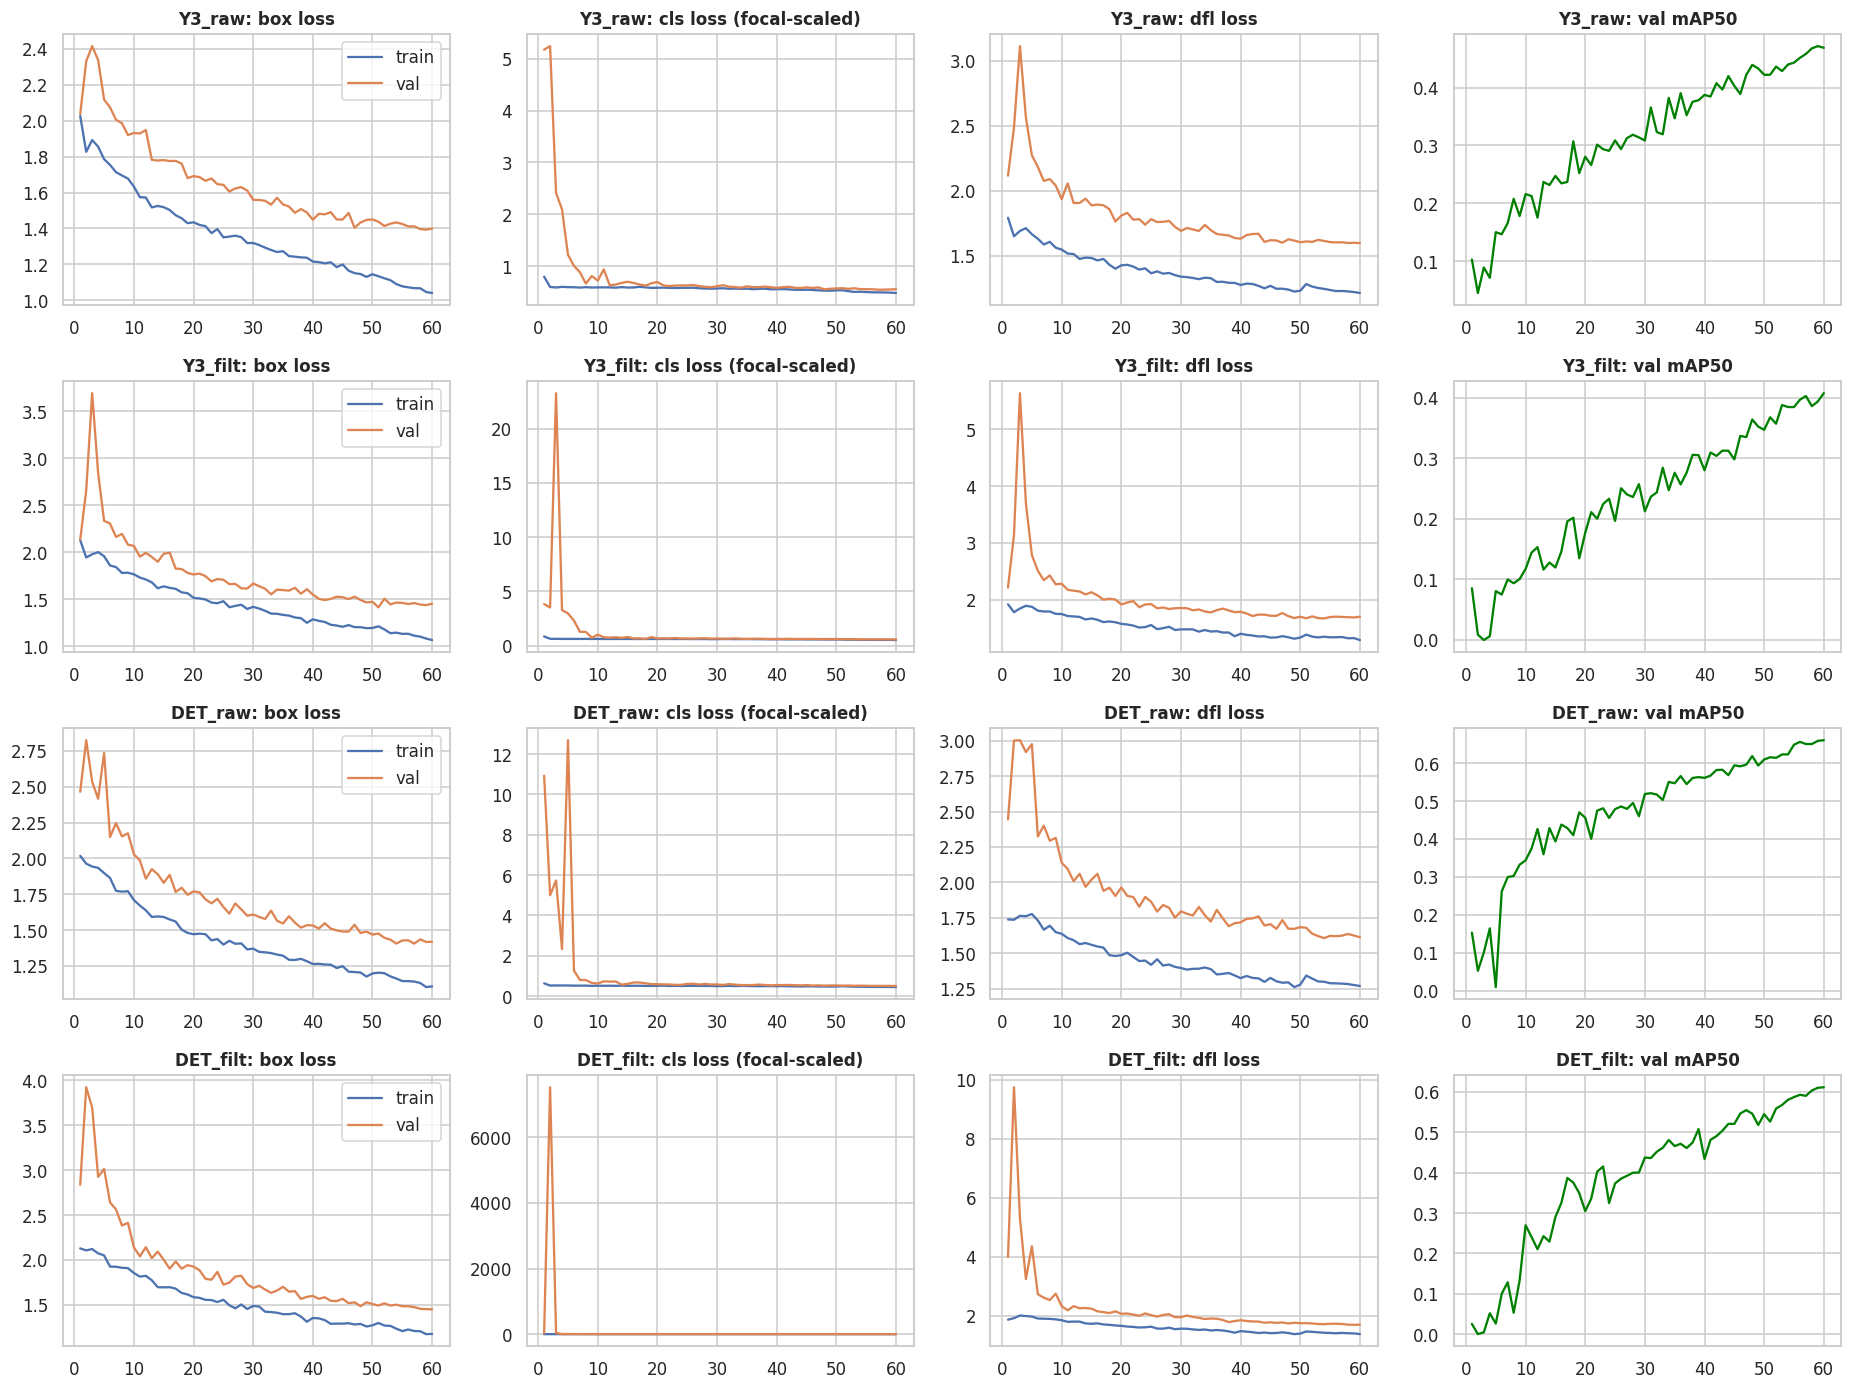

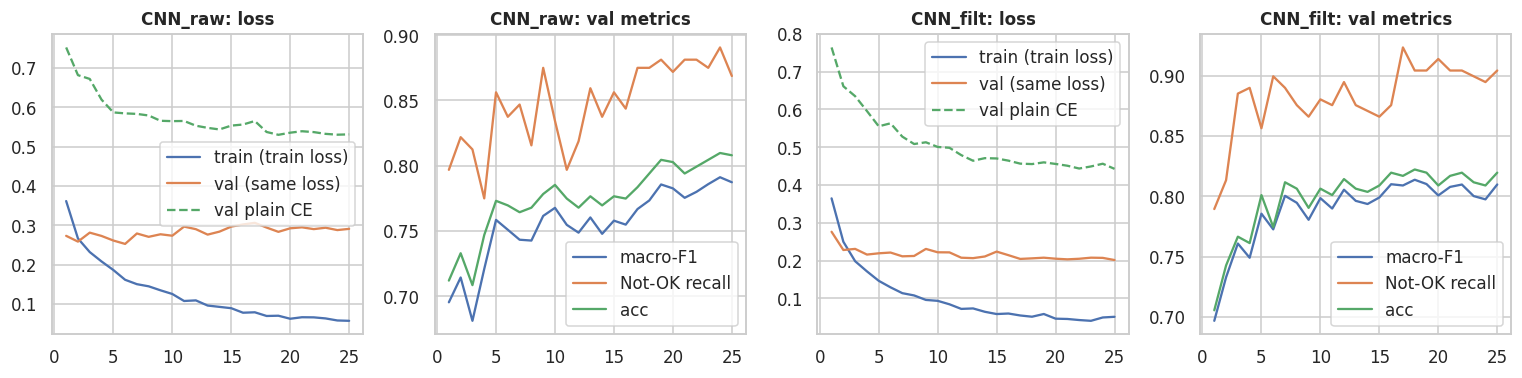

In [17]:
lg = LOG.df(); ep = lg[lg.record_type == "epoch"]
yolo_models = [m for m in ep.model_name.unique() if m.startswith(("Y3", "DET"))]
fig, axs = plt.subplots(len(yolo_models), 4, figsize=(17, 3.2 * len(yolo_models)), squeeze=False)
for r, m in enumerate(yolo_models):
    e = ep[ep.model_name == m]
    for c, k in enumerate(["box", "cls", "dfl"]):
        axs[r, c].plot(e.epoch, e[f"train_{k}"], label="train"); axs[r, c].plot(e.epoch, e[f"val_{k}"], label="val"); axs[r, c].set_title(f"{m}: {k} loss")
    axs[r, 3].plot(e.epoch, e.val_map50, color="green"); axs[r, 3].set_title(f"{m}: val mAP50"); axs[r, 0].legend()
    axs[r, 1].set_title(f"{m}: cls loss" + (" (focal-scaled)" if "focal" in str(e.loss_fn.iloc[0]) else ""))
plt.tight_layout(); plt.show()
cnn_models = [m for m in ep.model_name.unique() if m.startswith("CNN")]
fig, axs = plt.subplots(1, 2 * len(cnn_models), figsize=(7 * len(cnn_models), 3.6), squeeze=False)
for i, m in enumerate(cnn_models):
    e = ep[ep.model_name == m]; a, b = axs[0, 2 * i], axs[0, 2 * i + 1]
    a.plot(e.epoch, e.train_loss, label="train (train loss)"); a.plot(e.epoch, e.val_loss, label="val (same loss)"); a.plot(e.epoch, e.val_ce, "--", label="val plain CE"); a.legend(); a.set_title(f"{m}: loss")
    b.plot(e.epoch, e.val_macro_f1, label="macro-F1"); b.plot(e.epoch, e.val_bad_recall, label="Not-OK recall"); b.plot(e.epoch, e.val_acc, label="acc"); b.legend(); b.set_title(f"{m}: val metrics")
plt.tight_layout(); plt.show()

## 12. Inference for all four systems (val + test, raw images)
* `Y3_raw`, `Y3_filt` - Method A (single YOLO, 3 classes)
* `P2_raw`, `P2_filt` - Method B (`DET_*` weld detector -> `CNN_*` crop classifier). Box score for class k = `det_conf x p_cnn(k)`.

Predictions are computed once with a low confidence floor and cached; all later steps (slices, calibration, thresholds) reuse them.

In [18]:
PIPES = {"Y3_raw": dict(kind="yolo", det="Y3_raw"), "Y3_filt": dict(kind="yolo", det="Y3_filt"),
         "P2_raw": dict(kind="two", det="DET_raw", cnn="CNN_raw"), "P2_filt": dict(kind="two", det="DET_filt", cnn="CNN_filt")}
for p, c in PIPES.items():
    if c["kind"] == "yolo": LOG.meta[p] = dict(LOG.meta[c["det"]], run_id=LOG.meta[c["det"]]["run_id"], component="pipeline")
    else: LOG.meta[p] = dict(LOG.meta[c["det"]], component="pipeline", arch=f"{yolo_arch_name()}(det)+efficientnet_b0(cls)", loss_fn=f'{LOG.meta[c["det"]]["loss_fn"]} | {LOG.meta[c["cnn"]]["loss_fn"]}')

def yolo_predict(weights, paths, conf=0.01, iou=0.6, bs=16):
    m = YOLO(str(weights)); out = []; t0 = time.perf_counter()
    for i in range(0, len(paths), bs):
        for r in m.predict(paths[i:i + bs], imgsz=HP["imgsz"], conf=conf, iou=iou, max_det=100, device=DEVICE, verbose=False):
            b = r.boxes; out.append(dict(boxes=b.xyxyn.cpu().numpy().astype(np.float32), scores=b.conf.cpu().numpy(), cls=b.cls.cpu().numpy().astype(int)))
    return out, (time.perf_counter() - t0) / max(len(paths), 1) * 1000

def predict_paths(pipe, paths):
    c = PIPES[pipe]
    if c["kind"] == "yolo":
        out, ms = yolo_predict(WTS[c["det"]], paths, conf=0.01)
        return [dict(kind="yolo", **o) for o in out], ms
    t0 = time.perf_counter(); dets, _ = yolo_predict(WTS[c["det"]], paths, conf=0.05); out = []
    for p, d in zip(paths, dets):
        if len(d["boxes"]) == 0: out.append(dict(kind="two", boxes=np.zeros((0, 4), np.float32), det=np.zeros(0), logits=np.zeros((0, 3), np.float32))); continue
        img = read_rgb(p); crops = np.stack([extract_crop(img, b) for b in d["boxes"]])
        out.append(dict(kind="two", boxes=d["boxes"], det=d["scores"], logits=cnn_logits_u8(CNN[c["cnn"]], crops)))
    return out, (time.perf_counter() - t0) / max(len(paths), 1) * 1000

PRED, LAT = {}, {}
for pipe in PIPES:
    PRED[pipe] = {}
    for sp in ("valid", "test"):
        stems = EV[sp]["raw"]; outs, ms = predict_paths(pipe, [IMG_PATH[(sp, s)] for s in stems]); PRED[pipe][sp] = dict(zip(stems, outs)); LAT[pipe] = ms
    print(f"{pipe}: {LAT[pipe]:.1f} ms/img")

Y3_raw: 19.1 ms/img
Y3_filt: 19.2 ms/img
P2_raw: 369.4 ms/img
P2_filt: 255.6 ms/img


## 13. Requirement 3 - losses & metrics: overall, by box count, by area, raw vs filtered (cond 1+2)
* **Loss** (YOLO box/cls/dfl, plain BCE, per image, then averaged over the slice's images). Method B additionally has the **CNN crop cross-entropy** on ground-truth crops (`clf_ce`). Losses of the 3-class YOLO and the 1-class detector are *not* comparable with each other; detection metrics (mAP50, F1, class accuracy, Not-OK miss-rate) are.
* **Count slices** use the image's raw number of boxes. **Area slices**: images whose boxes are all >= threshold vs images containing at least one box < threshold; additionally box-level recall for boxes above/below the threshold.
* **Filtered** = conditions 1+2 applied to the val/test set (empty slices simply don't appear).
* All rows are appended to the CSV log (`record_type="eval"`).

In [19]:
LOSS = {}
for name in ("Y3_raw", "Y3_filt", "DET_raw", "DET_filt"):
    LOSS[name] = {sp: yolo_eval_losses(WTS[name], sp, {"raw": GT[sp]["raw"], "filt": GT[sp]["filt"]}, HP["imgsz"], collapse=name.startswith("DET")) for sp in ("valid", "test")}

def gt_crop_ce(cnn_model, split):
    rids = np.concatenate([g["rid"] for g in GT[split]["raw"].values()]); lg = cnn_logits_u8(cnn_model, CROPS[[RID[r] for r in rids]])
    y = LABELS[[RID[r] for r in rids]]; ce = F.cross_entropy(torch.tensor(lg), torch.tensor(y), reduction="none").numpy()
    return dict(zip(rids, ce)), dict(zip(rids, lg))
CE = {p: {sp: gt_crop_ce(CNN[c["cnn"]], sp)[0] for sp in ("valid", "test")} for p, c in PIPES.items() if c["kind"] == "two"}

def run_sliced_eval(pipe, T=1.0):
    c = PIPES[pipe]; LOG.drop(pipe, "eval"); rows = []
    for sp in ("valid", "test"):
        for mode in ("raw", "filt"):
            stems, gt = EV[sp][mode], GT[sp][mode]
            P = {s: (PRED[pipe][sp][s] if mode == "raw" else filter_area(PRED[pipe][sp][s])) for s in stems}
            ent = {s: to_entries(P[s], T) for s in stems}; sc = {s: image_scores(P[s], T) for s in stems}
            ld = LOSS[c["det"]][sp][mode]
            for (stype, sval), ss in make_slices(stems, sp).items():
                if not ss: continue
                m = det_metrics(ss, gt, ent); y = np.array([int(np.isin(gt[s]["cls"], BAD_IDS).any()) for s in ss]); sb = np.array([sc[s][0] for s in ss])
                row = dict(split=sp, mode=mode, slice_type=stype, slice_value=sval, n_images=len(ss), n_boxes=m["n_gt"],
                           loss_box=ld.loc[ss, "box"].mean(), loss_cls=ld.loc[ss, "cls"].mean(), loss_dfl=ld.loc[ss, "dfl"].mean(), loss_total=ld.loc[ss, "total"].mean(),
                           map50=m["map50"], ap_bad=m["ap_bad"], ap_good=m["ap_good"], ap_defect=m["ap_defect"], precision=m["precision"], recall=m["recall"], f1=m["f1"], cls_acc=m["cls_acc"],
                           recall_above_thr=m["recall_above_thr"], recall_below_thr=m["recall_below_thr"],
                           img_miss_rate_t025=float(((sb < 0.25) & (y == 1)).sum() / max(y.sum(), 1)) if y.sum() else np.nan, n_notok_images=int(y.sum()))
                if c["kind"] == "two":
                    ces = [CE[pipe][sp][r] for s in ss for r in gt[s]["rid"]]; row["clf_ce"] = float(np.mean(ces)) if ces else np.nan
                LOG.add(pipe, "eval", **row)
    LOG.save()

for pipe in PIPES: run_sliced_eval(pipe)
EVAL = LOG.df().query("record_type=='eval'").copy()
EVAL["slice"] = np.where(EVAL.slice_type == "overall", "overall", np.where(EVAL.slice_type == "count", "count=" + EVAL.slice_value.astype(str), "area: " + EVAL.slice_value.astype(str)))
order = ["overall"] + ["count=" + b for b in CFG["COUNT_LABELS"]] + ["area: all boxes >= thr", "area: has box < thr"]
print(EVAL.query("slice_type=='overall'")[["model_name", "split", "mode", "n_images", "n_boxes", "loss_total", "loss_box", "loss_cls", "loss_dfl", "clf_ce", "map50", "f1", "cls_acc", "img_miss_rate_t025"]].round(3).to_string(index=False))

model_name split mode  n_images  n_boxes  loss_total  loss_box  loss_cls  loss_dfl  clf_ce  map50    f1  cls_acc  img_miss_rate_t025
    Y3_raw valid  raw     176.0    573.0      14.440     1.473    11.283     1.685     NaN  0.478 0.472    0.704               0.154
    Y3_raw valid filt     156.0    377.0      15.265     1.473    12.047     1.745     NaN  0.438 0.450    0.694               0.136
    Y3_raw  test  raw      74.0    209.0      17.810     1.476    14.669     1.665     NaN  0.423 0.405    0.632               0.067
    Y3_raw  test filt      66.0    133.0      17.129     1.440    14.003     1.686     NaN  0.378 0.381    0.619               0.079
   Y3_filt valid  raw     176.0    573.0      14.643     1.519    11.396     1.729     NaN  0.414 0.458    0.689               0.269
   Y3_filt valid filt     156.0    377.0      15.405     1.516    12.109     1.780     NaN  0.411 0.443    0.668               0.295
   Y3_filt  test  raw      74.0    209.0      17.297     1.559    14.

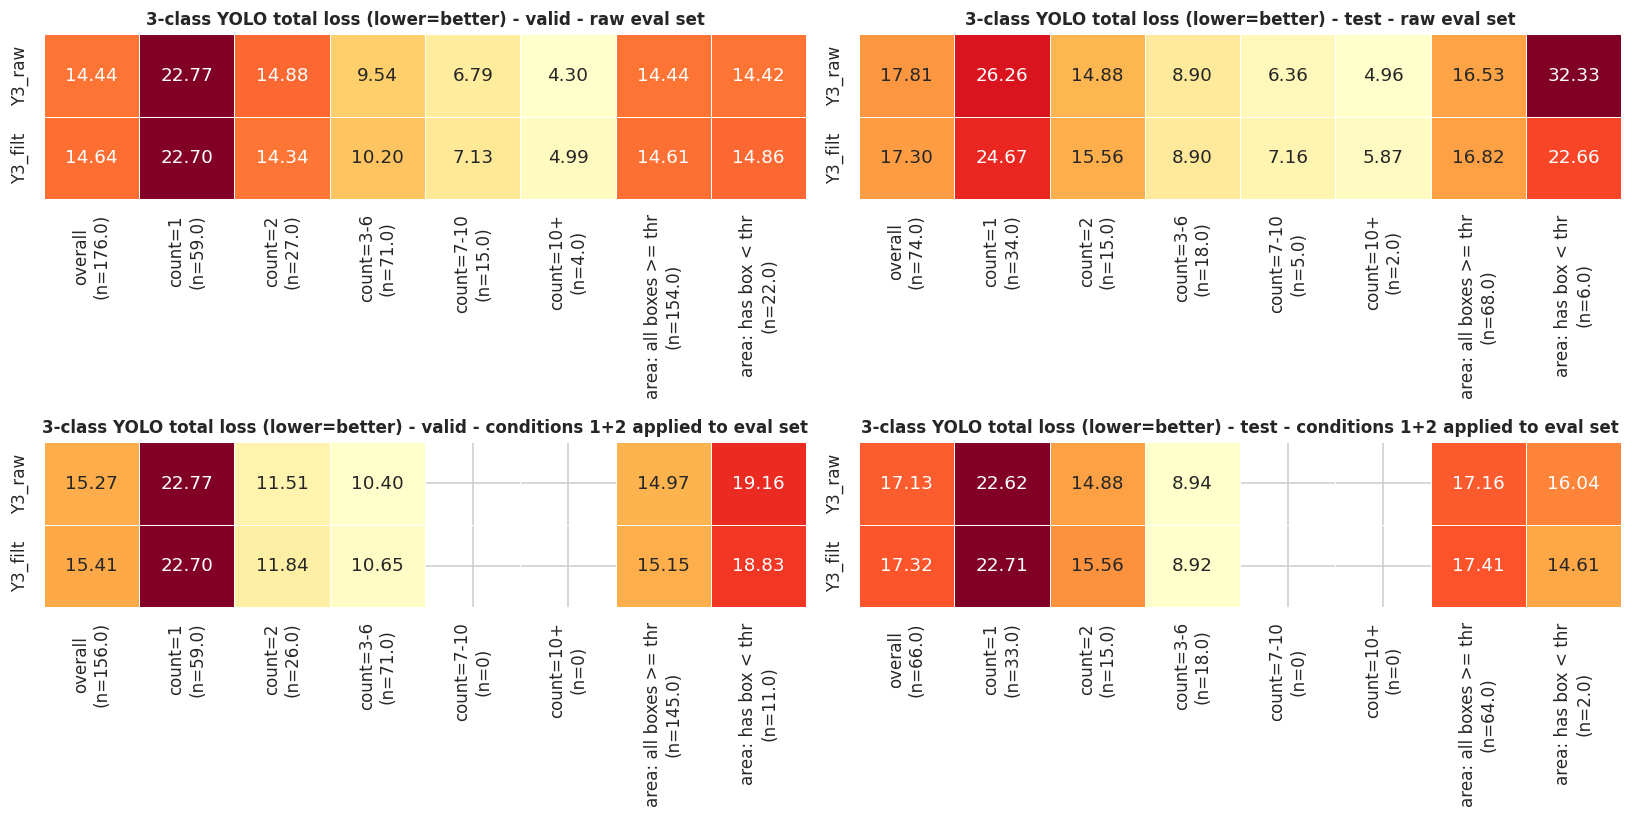

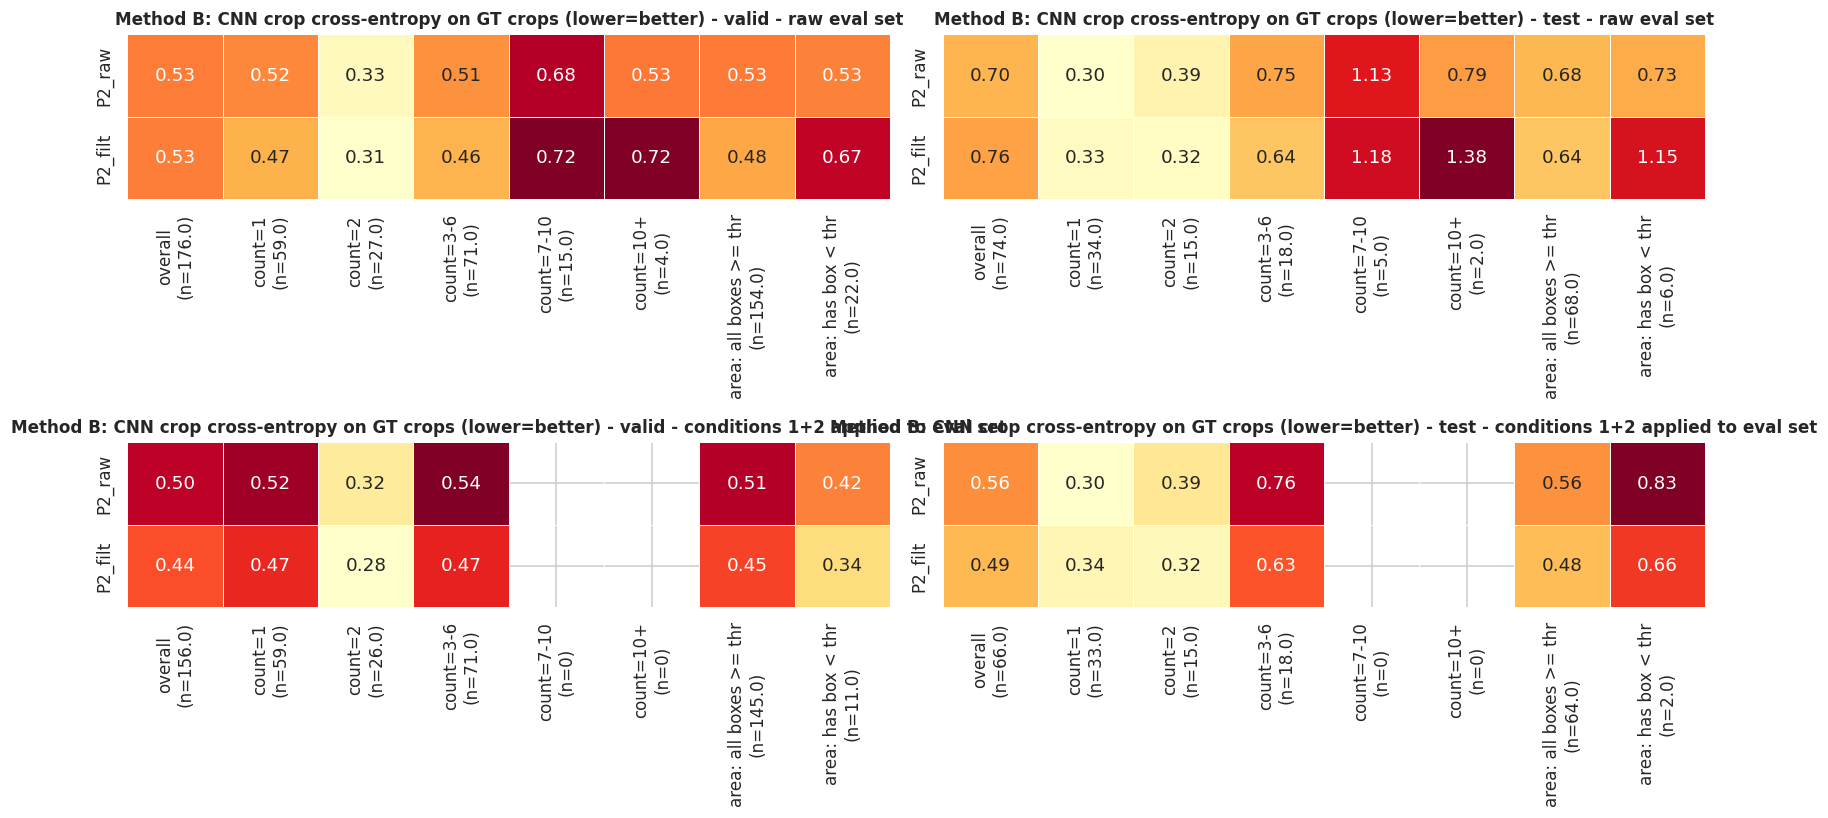

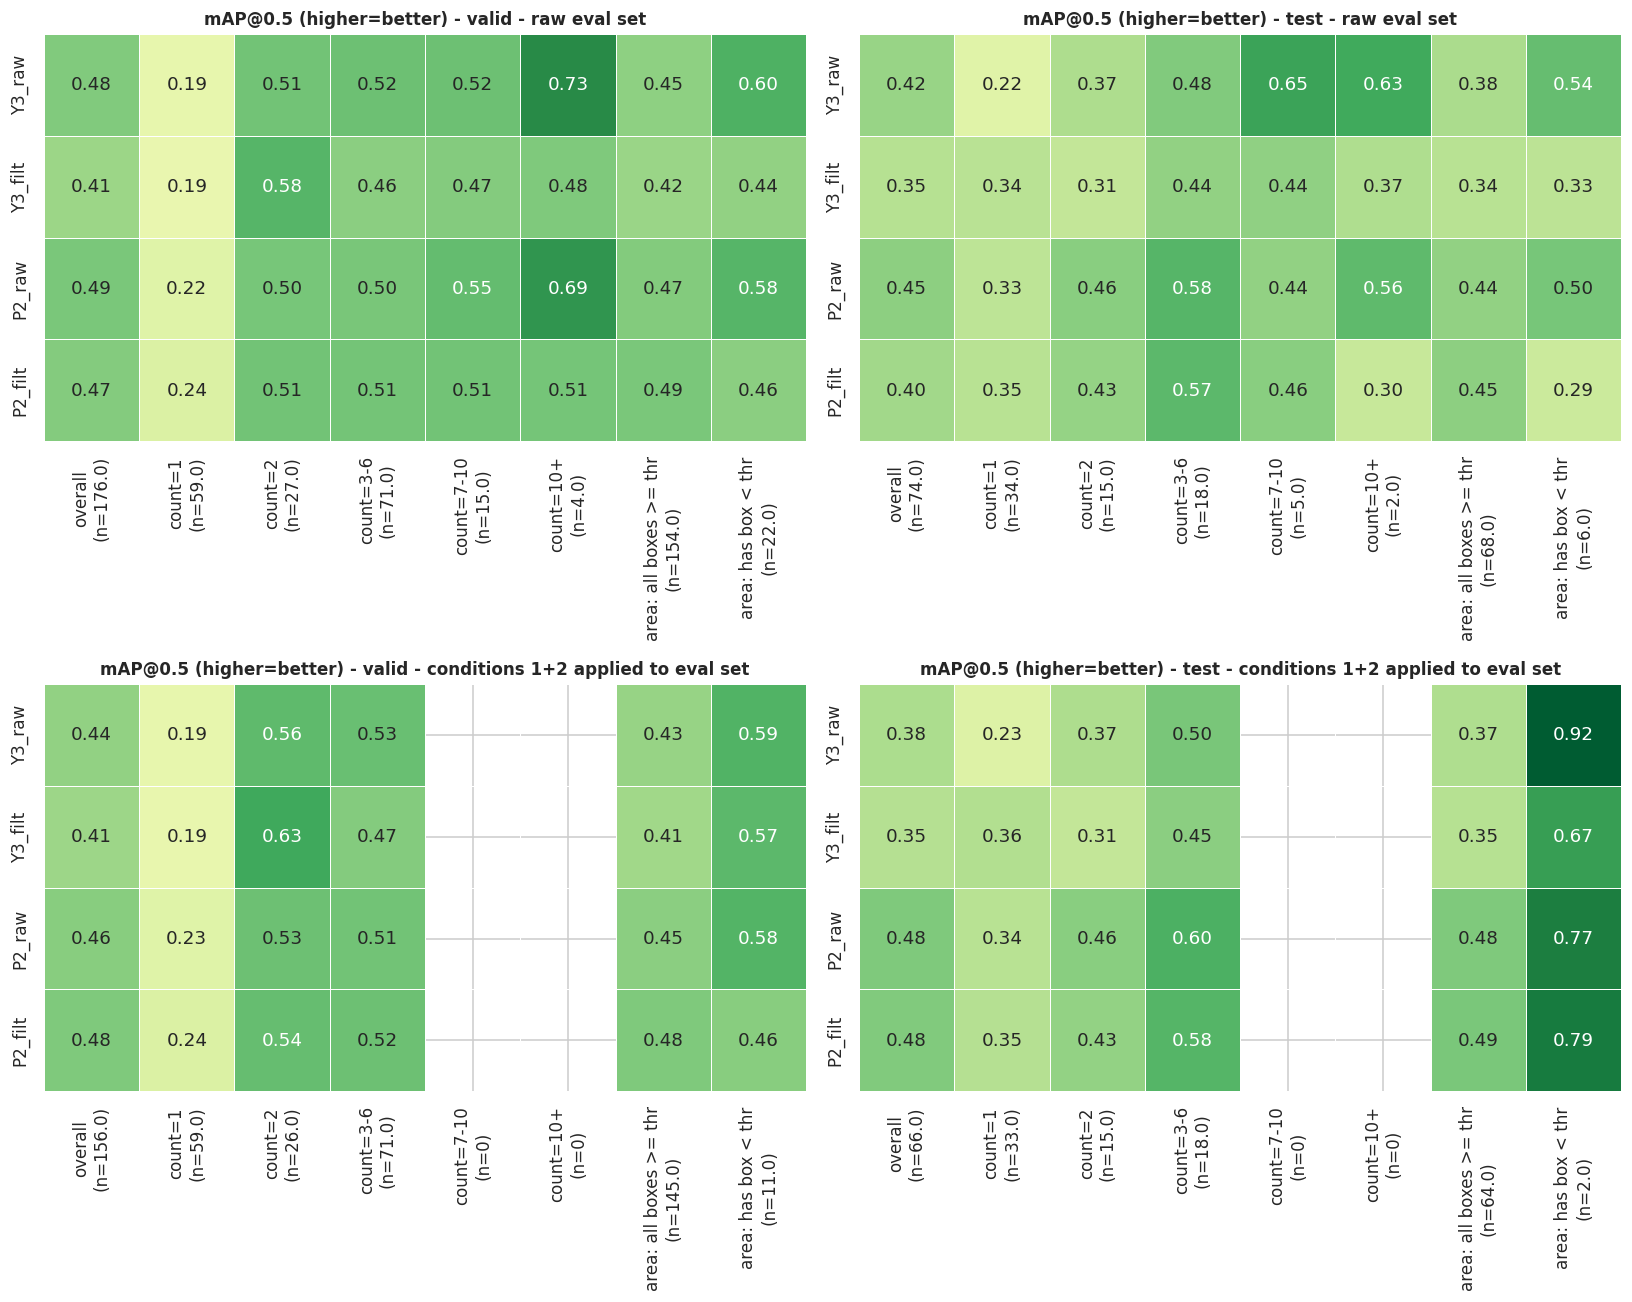

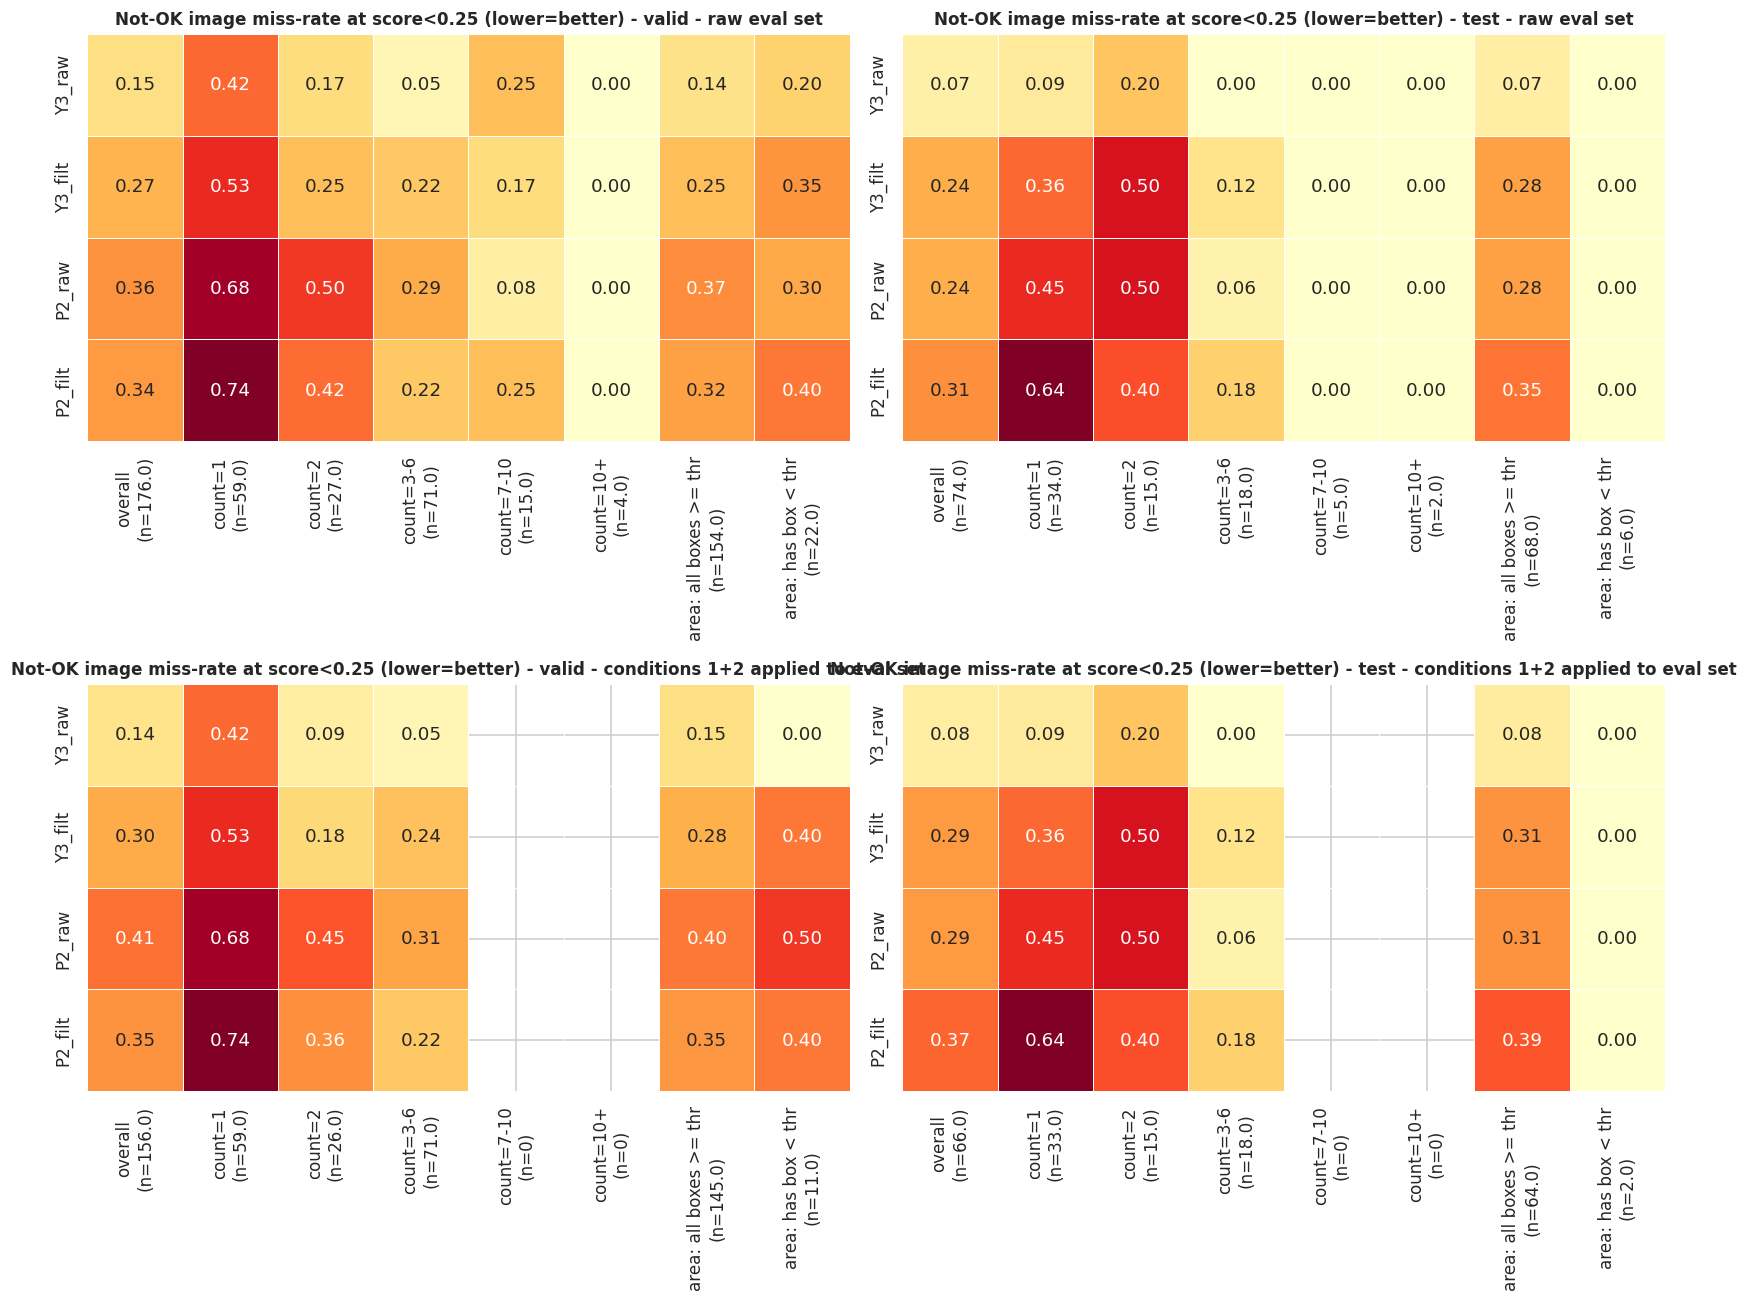

In [20]:
def heat(metric, models, title, cmap, fmt=".2f", vmin=None, vmax=None):
    fig, axs = plt.subplots(2, 2, figsize=(15, 2.2 * len(models) + 3.2), squeeze=False); m0 = models[0]
    for r, mode in enumerate(("raw", "filt")):
        for c, sp in enumerate(("valid", "test")):
            d = EVAL.query("split==@sp and mode==@mode and model_name in @models").pivot_table(index="model_name", columns="slice", values=metric).reindex(index=models, columns=[o for o in order if o in EVAL.slice.unique()])
            n = EVAL.query("split==@sp and mode==@mode and model_name==@m0").set_index("slice").n_images.to_dict()
            d.columns = [f"{k}\n(n={n.get(k, 0)})" for k in d.columns]
            sns.heatmap(d, annot=True, fmt=fmt, cmap=cmap, ax=axs[r, c], cbar=False, vmin=vmin, vmax=vmax, linewidths=.5); axs[r, c].set_ylabel(""); axs[r, c].set_xlabel("")
            axs[r, c].set_title(f"{title} - {sp} - {'raw eval set' if mode == 'raw' else 'conditions 1+2 applied to eval set'}")
    plt.tight_layout(); plt.show()

heat("loss_total", ["Y3_raw", "Y3_filt"], "3-class YOLO total loss (lower=better)", "YlOrRd")
heat("clf_ce", ["P2_raw", "P2_filt"], "Method B: CNN crop cross-entropy on GT crops (lower=better)", "YlOrRd")
heat("map50", list(PIPES), "mAP@0.5 (higher=better)", "YlGn", vmin=0, vmax=1)
heat("img_miss_rate_t025", list(PIPES), "Not-OK image miss-rate at score<0.25 (lower=better)", "YlOrRd")

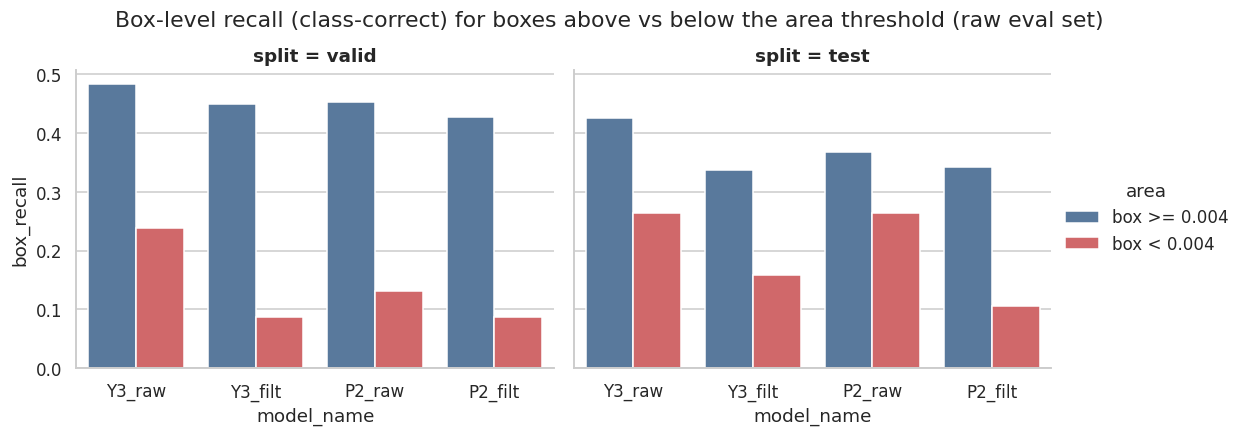

In [21]:
# box-level recall by area
ar = EVAL.query("slice_type=='overall'").melt(id_vars=["model_name", "split", "mode"], value_vars=["recall_above_thr", "recall_below_thr"], var_name="area", value_name="box_recall")
ar["area"] = ar.area.map({"recall_above_thr": f"box >= {CFG['AREA_THR']}", "recall_below_thr": f"box < {CFG['AREA_THR']}"})
g = sns.catplot(data=ar.query("mode=='raw'"), x="model_name", y="box_recall", hue="area", col="split", kind="bar", height=3.8, aspect=1.3, palette=["#4e79a7", "#e15759"])
g.fig.suptitle("Box-level recall (class-correct) for boxes above vs below the area threshold (raw eval set)", y=1.04); plt.show()

## 14. Confidence, calibration, learned thresholds & human review (requirements 6, 7, 9)
**Score.** `s_bad` = confidence that an image contains a Bad Weld/Defect (Method A: highest Bad/Defect box confidence; Method B: `max det_conf x (p_bad + p_defect)`). `s_any` = confidence that *any* weld was found.

**Calibrate only when needed.** If validation ECE > `ECE_TOL`, choose among {none, Platt, isotonic} by 5-fold CV Brier on val. Method B's CNN also gets temperature scaling when its crop-level ECE is too high.

**Decision policy (learned on val, bootstrap-conservative):**
* `s_bad <= t_pass` -> **PASS**. `t_pass` is the *largest* threshold such that at most `FN_TARGET` of the truly Not-OK val images would be passed (FN priority), then lowered to the 10th percentile of bootstrap re-estimates.
* `s_bad >= t_reject` -> **REJECT**, only where auto-reject precision >= `REJECT_PREC_TARGET` (90th-percentile bootstrap).
* anything in between, or `s_any < t_any` (no weld found) -> **REVIEW** (human). Equivalent to "verdict confidence below a learned threshold -> human".

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.optimize import minimize_scalar
from scipy.stats import beta as beta_dist

def ece_score(p, y, n_bins=10):
    b = np.minimum((p * n_bins).astype(int), n_bins - 1); e = 0.0
    for k in range(n_bins):
        m = b == k
        if m.any(): e += m.mean() * abs(y[m].mean() - p[m].mean())
    return float(e)
def reliability(p, y, n_bins=10):
    b = np.minimum((p * n_bins).astype(int), n_bins - 1); return [(p[b == k].mean(), y[b == k].mean(), (b == k).sum()) for k in range(n_bins) if (b == k).any()]
def cp_ci(k, n, a=0.05):
    if n == 0: return (np.nan, np.nan)
    return (0.0 if k == 0 else beta_dist.ppf(a / 2, k, n - k + 1), 1.0 if k == n else beta_dist.ppf(1 - a / 2, k + 1, n - k))

class Calibrator:
    def __init__(self, kind="none"): self.kind = kind; self.m = None
    @staticmethod
    def _lg(s): s = np.clip(s, 1e-4, 1 - 1e-4); return np.log(s / (1 - s)).reshape(-1, 1)
    def fit(self, s, y):
        if self.kind == "platt": self.m = LogisticRegression(C=1e4).fit(self._lg(s), y)
        elif self.kind == "isotonic": self.m = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip").fit(s, y)
        return self
    def transform(self, s):
        if self.kind == "platt": return self.m.predict_proba(self._lg(s))[:, 1]
        if self.kind == "isotonic": return self.m.predict(s)
        return np.asarray(s, float)

def choose_calibrator(s, y, tol=CFG["ECE_TOL"], seed=0):
    e0, b0 = ece_score(s, y), brier_score_loss(y, s); info = dict(ece_before=e0, brier_before=b0, needed=bool(e0 > tol), chosen="none", cv_brier={})
    if e0 <= tol or min(np.bincount(y, minlength=2)) < 3: return Calibrator("none"), info
    skf = StratifiedKFold(min(5, int(min(np.bincount(y)))), shuffle=True, random_state=seed)
    for kind in ("platt", "isotonic"):
        oof = np.zeros(len(s))
        for tr, te in skf.split(s, y): oof[te] = Calibrator(kind).fit(s[tr], y[tr]).transform(s[te])
        info["cv_brier"][kind] = brier_score_loss(y, oof)
    best = min(info["cv_brier"], key=info["cv_brier"].get)
    if info["cv_brier"][best] < b0: info["chosen"] = best; return Calibrator(best).fit(s, y), info
    return Calibrator("none"), info

def fit_temperature(logits, y):
    f = lambda lt: F.cross_entropy(torch.tensor(logits / np.exp(lt)), torch.tensor(y)).item()
    return float(np.exp(minimize_scalar(f, bounds=(-3, 3), method="bounded").x))
def ece_topclass(logits, y, T=1.0):
    p = softmax_np(logits, T); return ece_score(p.max(1), (p.argmax(1) == y).astype(float))

# --- policy learning ---------------------------------------------------------------------------------------------
def t_pass_from(s, y, fn_target):
    sb = np.sort(s[y == 1]); nb = len(sb)
    if nb == 0: return 1.0
    k = int(np.floor(fn_target * nb)); return 1.0 if k >= nb else float(np.nextafter(sb[k], -np.inf))       # at most k Not-OK images can score <= t
def t_reject_from(s, y, prec_target, min_support=5):
    o = np.argsort(-s); yy = y[o]; n = np.arange(1, len(yy) + 1); cum = np.cumsum(yy) / n; ok = np.where((cum >= prec_target) & (n >= min_support))[0]
    return 1.01 if len(ok) == 0 else float(s[o][ok.max()])
def learn_policy(s, y, s_any, seed=0):
    rng = np.random.RandomState(seed); n = len(s); tp, tr = [], []
    for _ in range(CFG["N_BOOT"]):
        i = rng.randint(0, n, n); tp.append(t_pass_from(s[i], y[i], CFG["FN_TARGET"])); tr.append(t_reject_from(s[i], y[i], CFG["REJECT_PREC_TARGET"]))
    t_pass = float(min(np.quantile(tp, 0.10), t_pass_from(s, y, CFG["FN_TARGET"]))); t_rej = float(max(np.quantile(tr, 0.90), t_pass + 1e-6))
    return dict(t_pass=t_pass, t_reject=t_rej, t_any=float(np.quantile(s_any, 0.05)), conf_thr_pass=1 - t_pass, conf_thr_reject=t_rej)
def apply_policy(s, s_any, pol):
    return np.where(s_any < pol["t_any"], "REVIEW", np.where(s <= pol["t_pass"], "PASS", np.where(s >= pol["t_reject"], "REJECT", "REVIEW")))
def policy_report(v, y):
    nb, n = int((y == 1).sum()), len(y); fn = int(((v == "PASS") & (y == 1)).sum()); rej = v == "REJECT"; lo, hi = cp_ci(fn, nb)
    return dict(n=n, n_pass=int((v == "PASS").sum()), n_reject=int(rej.sum()), n_review=int((v == "REVIEW").sum()), review_rate=float((v == "REVIEW").mean()),
                automation=float((v != "REVIEW").mean()), fn=fn, n_notok=nb, miss_rate=fn / max(nb, 1), miss_lo=lo, miss_hi=hi,
                reject_precision=float(y[rej].mean()) if rej.any() else np.nan, pass_npv=float(1 - y[v == "PASS"].mean()) if (v == "PASS").any() else np.nan)

CAL, POL, TEMP, SC = {}, {}, {}, {}
def scores(pipe, sp, T=1.0):
    st = EV[sp]["raw"]; a = np.array([image_scores(PRED[pipe][sp][s], T) for s in st]); return np.array(st), a[:, 0], a[:, 1], np.array([Y_BAD[sp][s] for s in st])

for pipe, c in PIPES.items():
    T = 1.0; LOG.drop(pipe, "calibration"); LOG.drop(pipe, "policy")
    if c["kind"] == "two":                                             # CNN temperature scaling (only if needed)
        ce_v, lg_v = gt_crop_ce(CNN[c["cnn"]], "valid"); rids = list(lg_v); lgv = np.stack([lg_v[r] for r in rids]); yv = LABELS[[RID[r] for r in rids]]
        e0 = ece_topclass(lgv, yv); T = fit_temperature(lgv, yv) if e0 > CFG["ECE_TOL"] else 1.0
        LOG.add(pipe, "calibration", slice_type="cnn_temperature", ece_before=e0, ece_after=ece_topclass(lgv, yv, T), extra=json.dumps(dict(T=T, needed=bool(e0 > CFG["ECE_TOL"]))))
        print(f"{pipe}: CNN crop ECE {e0:.3f} -> {ece_topclass(lgv, yv, T):.3f}  (T={T:.2f}, {'applied' if e0 > CFG['ECE_TOL'] else 'not needed'})")
    TEMP[pipe] = T
    sv = scores(pipe, "valid", T); st_ = scores(pipe, "test", T)
    cal, info = choose_calibrator(sv[1], sv[3]); CAL[pipe] = cal
    cv, ct = cal.transform(sv[1]), cal.transform(st_[1])
    pol = learn_policy(cv, sv[3], sv[2]); POL[pipe] = pol
    SC[pipe] = dict(valid=dict(stem=sv[0], raw=sv[1], cal=cv, any=sv[2], y=sv[3]), test=dict(stem=st_[0], raw=st_[1], cal=ct, any=st_[2], y=st_[3]))
    LOG.add(pipe, "calibration", slice_type="image_score", slice_value=cal.kind, split="valid", ece_before=info["ece_before"], ece_after=ece_score(cv, sv[3]), brier_before=info["brier_before"], brier_after=brier_score_loss(sv[3], np.clip(cv, 0, 1)),
            extra=json.dumps(info, default=float))
    LOG.add(pipe, "policy", extra=json.dumps(dict(pol, fn_target=CFG["FN_TARGET"], reject_prec_target=CFG["REJECT_PREC_TARGET"], calibrator=cal.kind, temperature=T)))
    print(f"{pipe}: val ECE {info['ece_before']:.3f} -> calibrator={cal.kind:9s} | t_pass={pol['t_pass']:.3f}  t_reject={pol['t_reject']:.3f}  t_any={pol['t_any']:.3f}")
LOG.save()

Y3_raw: val ECE 0.237 -> calibrator=platt     | t_pass=0.356  t_reject=1.010  t_any=0.190
Y3_filt: val ECE 0.295 -> calibrator=platt     | t_pass=0.278  t_reject=1.010  t_any=0.183
P2_raw: CNN crop ECE 0.032 -> 0.032  (T=1.00, not needed)
P2_raw: val ECE 0.313 -> calibrator=isotonic  | t_pass=0.273  t_reject=0.750  t_any=0.187
P2_filt: CNN crop ECE 0.030 -> 0.030  (T=1.00, not needed)
P2_filt: val ECE 0.311 -> calibrator=platt     | t_pass=0.173  t_reject=0.868  t_any=0.190


PosixPath('weld_work/experiment_log.csv')

In [23]:
# Evaluate the learned policy on val (in-sample for thresholds) and test (untouched) --------------------------------------
rows = []
for pipe in PIPES:
    for sp in ("valid", "test"):
        d = SC[pipe][sp]; v = apply_policy(d["cal"], d["any"], POL[pipe]); r = policy_report(v, d["y"]); d["verdict"] = v
        base = lambda t: int(((d["raw"] < t) & (d["y"] == 1)).sum())
        auc = roc_auc_score(d["y"], d["cal"]) if len(set(d["y"])) > 1 else np.nan
        rows.append(dict(pipe=pipe, split=sp, auroc=auc, ece_raw=ece_score(d["raw"], d["y"]), ece_cal=ece_score(np.clip(d["cal"], 0, 1), d["y"]), brier_cal=brier_score_loss(d["y"], np.clip(d["cal"], 0, 1)),
                         naive_FN_at_0_5=base(0.5), naive_miss_at_0_5=base(0.5) / max(r["n_notok"], 1), **r))
        LOG.add(pipe, "eval", split=sp, mode="raw", slice_type="triage_policy", slice_value="learned", n_images=r["n"], n_boxes=np.nan, **{k: v_ for k, v_ in r.items() if k not in ("n",)}, auroc=auc)
LOG.save(); TRI = pd.DataFrame(rows)
show = ["pipe", "split", "auroc", "ece_raw", "ece_cal", "n_notok", "naive_FN_at_0_5", "fn", "miss_rate", "miss_lo", "miss_hi", "review_rate", "automation", "reject_precision", "pass_npv"]
print(TRI[show].round(3).to_string(index=False))

   pipe split  auroc  ece_raw  ece_cal  n_notok  naive_FN_at_0_5  fn  miss_rate  miss_lo  miss_hi  review_rate  automation  reject_precision  pass_npv
 Y3_raw valid  0.644    0.237    0.068      104               88   0        0.0      0.0    0.035        0.966       0.034               NaN       1.0
 Y3_raw  test  0.768    0.277    0.108       45               41   0        0.0      0.0    0.079        0.932       0.068               NaN       1.0
Y3_filt valid  0.672    0.295    0.042      104              100   0        0.0      0.0    0.035        0.972       0.028               NaN       1.0
Y3_filt  test  0.762    0.329    0.099       45               42   0        0.0      0.0    0.079        0.973       0.027               NaN       1.0
 P2_raw valid  0.799    0.313    0.000      104               82   0        0.0      0.0    0.035        0.676       0.324             0.921       1.0
 P2_raw  test  0.862    0.363    0.102       45               38   0        0.0      0.0    0.

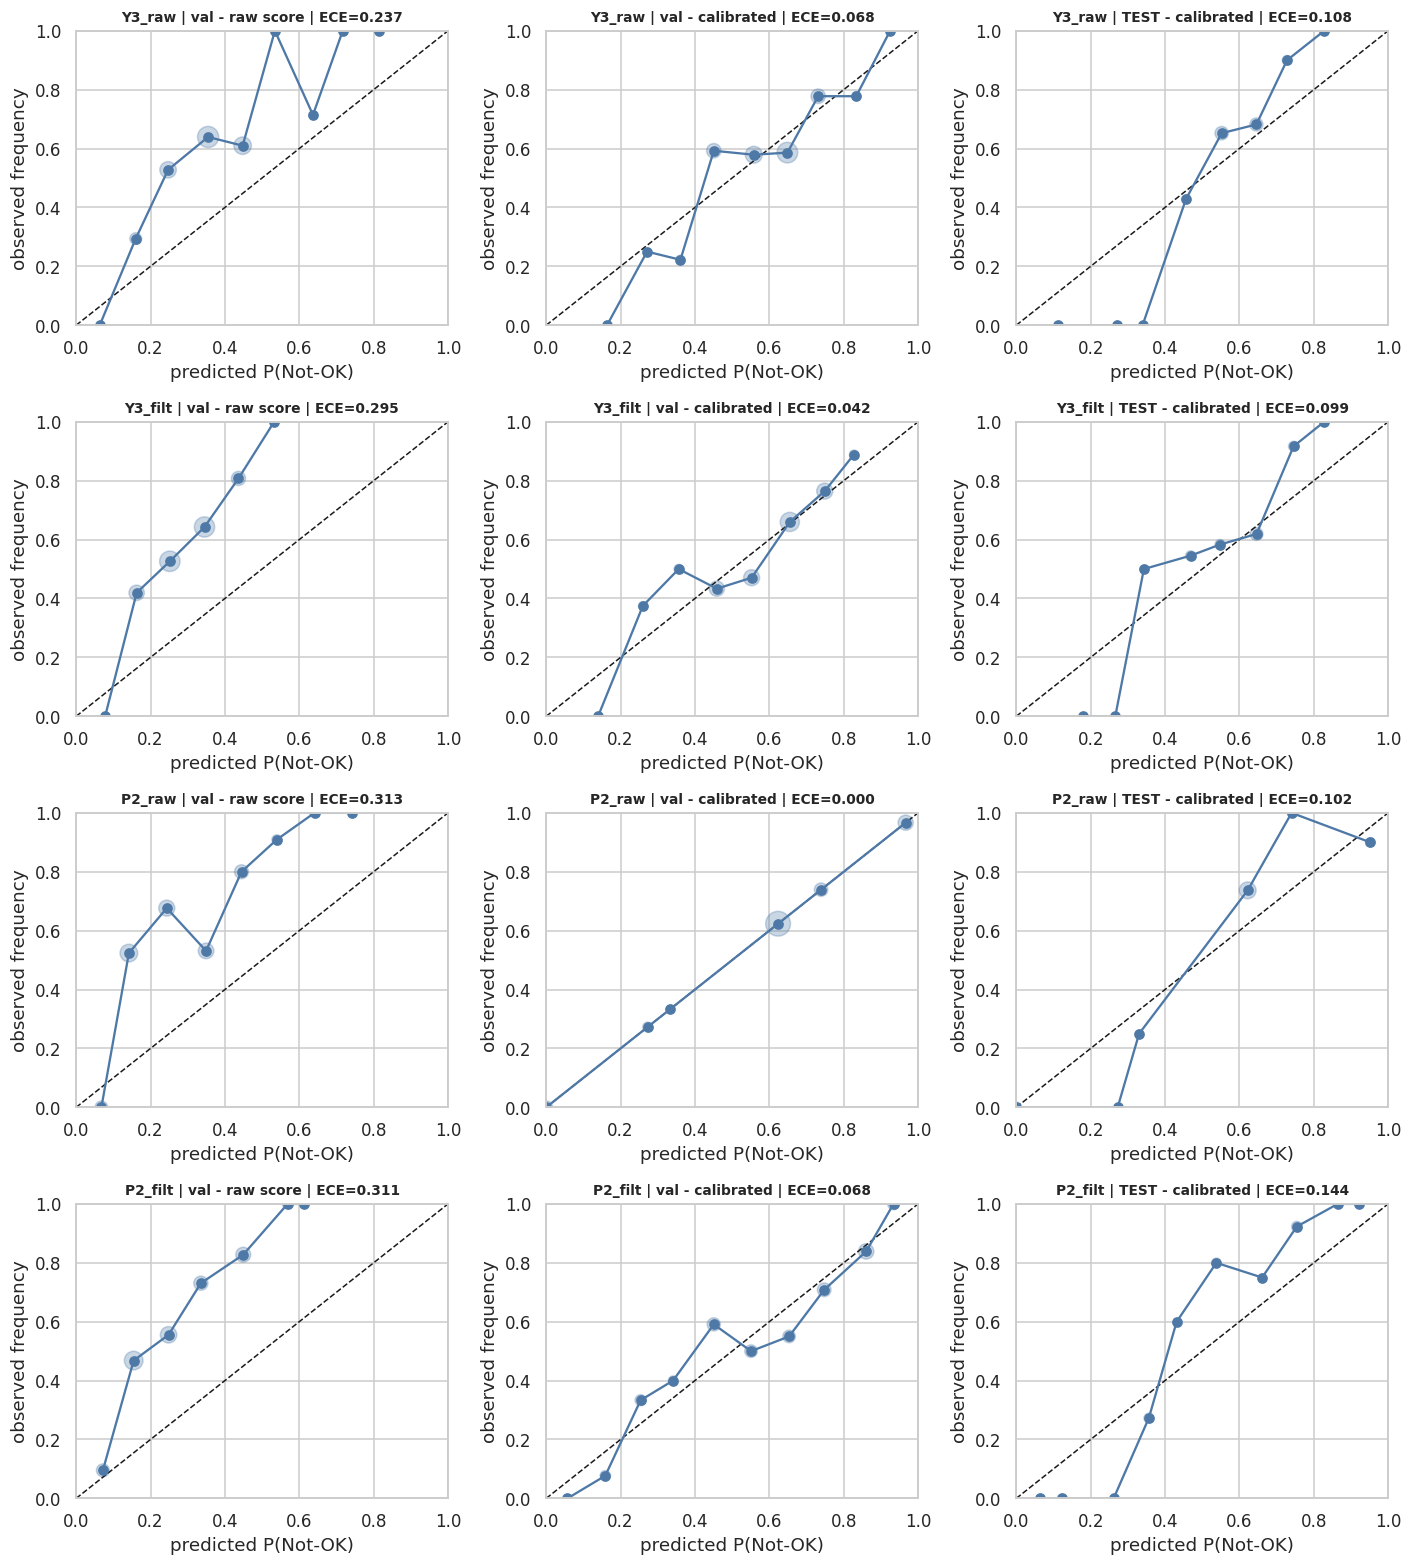

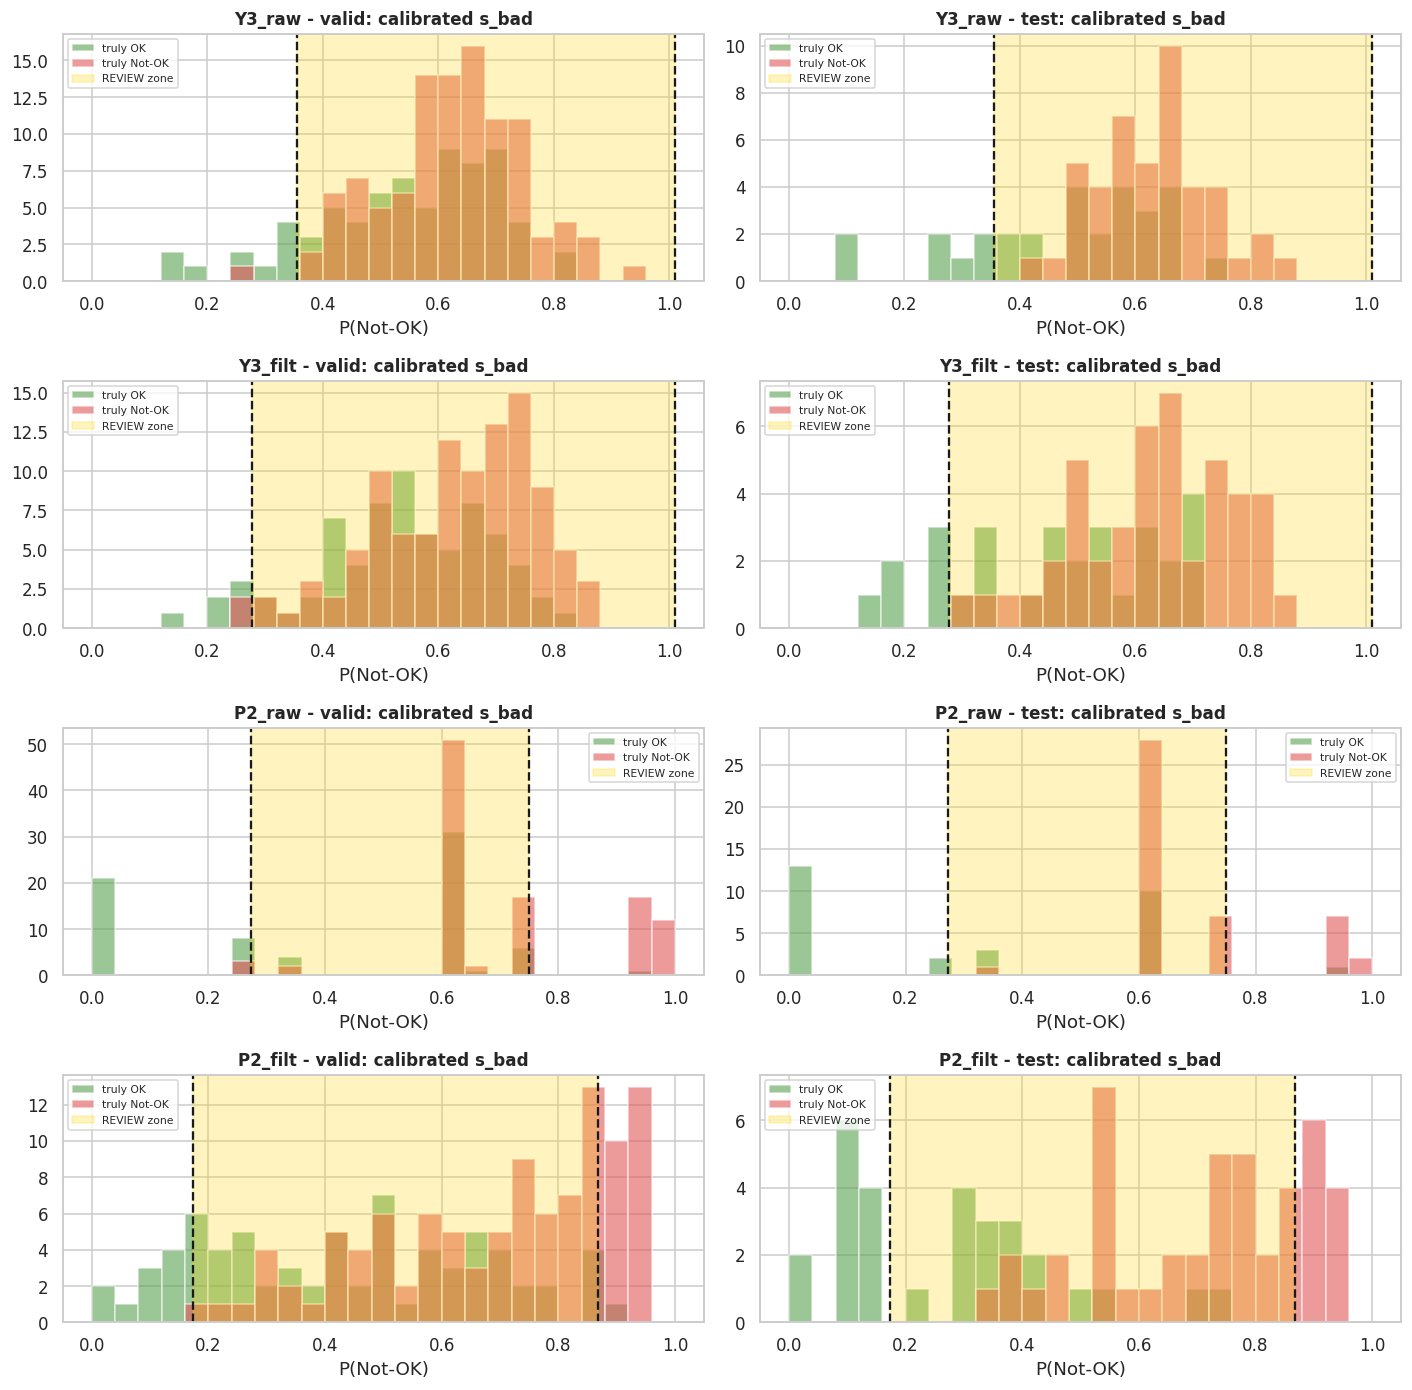

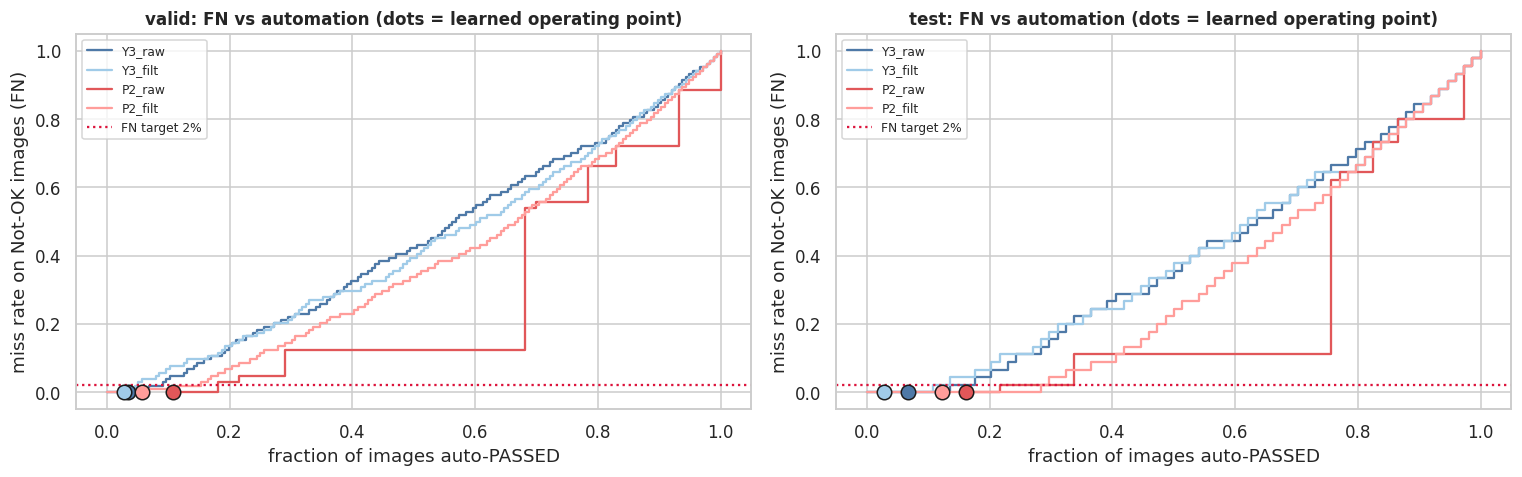

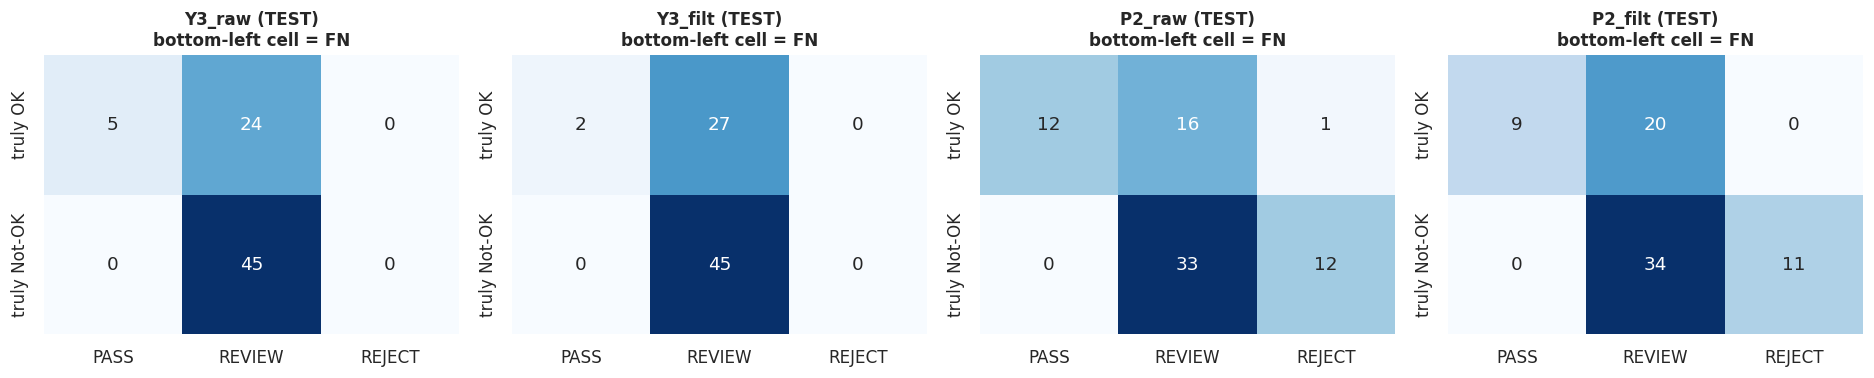

In [24]:
# --- Visual 1: reliability diagrams (raw vs calibrated) ----------------------------------------------------------------
fig, axs = plt.subplots(len(PIPES), 3, figsize=(13, 3.6 * len(PIPES)), squeeze=False)
for i, pipe in enumerate(PIPES):
    for j, (sp, key, ttl) in enumerate([("valid", "raw", "val - raw score"), ("valid", "cal", "val - calibrated"), ("test", "cal", "TEST - calibrated")]):
        d = SC[pipe][sp]; p = np.clip(d[key], 0, 1); a = axs[i, j]; a.plot([0, 1], [0, 1], "k--", lw=1)
        rl = reliability(p, d["y"]); a.plot([r[0] for r in rl], [r[1] for r in rl], "o-", color="#4e79a7"); a.scatter([r[0] for r in rl], [r[1] for r in rl], s=[8 + 3 * r[2] for r in rl], color="#4e79a7", alpha=.3)
        a.set_title(f"{pipe} | {ttl} | ECE={ece_score(p, d['y']):.3f}", fontsize=9); a.set_xlabel("predicted P(Not-OK)"); a.set_ylabel("observed frequency"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

# --- Visual 2: score distributions with the learned thresholds ----------------------------------------------------------
fig, axs = plt.subplots(len(PIPES), 2, figsize=(13, 3.2 * len(PIPES)), squeeze=False)
for i, pipe in enumerate(PIPES):
    for j, sp in enumerate(("valid", "test")):
        d = SC[pipe][sp]; a = axs[i, j]; bins = np.linspace(0, 1, 26)
        a.hist(d["cal"][d["y"] == 0], bins, alpha=.6, color=CLASS_COLORS[1], label="truly OK"); a.hist(d["cal"][d["y"] == 1], bins, alpha=.6, color=CLASS_COLORS[0], label="truly Not-OK")
        a.axvspan(POL[pipe]["t_pass"], POL[pipe]["t_reject"], color="gold", alpha=.25, label="REVIEW zone"); a.axvline(POL[pipe]["t_pass"], color="k", ls="--"); a.axvline(POL[pipe]["t_reject"], color="k", ls="--")
        a.set_title(f"{pipe} - {sp}: calibrated s_bad"); a.set_xlabel("P(Not-OK)"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

# --- Visual 3: FN-vs-workload trade-off ------------------------------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
for j, sp in enumerate(("valid", "test")):
    for pipe, col in zip(PIPES, ["#4e79a7", "#a0cbe8", "#e15759", "#ff9d9a"]):
        d = SC[pipe][sp]; ts = np.unique(np.r_[0, d["cal"], 1]); nb = max((d["y"] == 1).sum(), 1)
        miss = [((d["cal"] <= t) & (d["y"] == 1)).sum() / nb for t in ts]; passed = [(d["cal"] <= t).mean() for t in ts]
        axs[j].step(passed, miss, where="post", color=col, label=pipe)
        v = d["verdict"]; axs[j].scatter([(v == "PASS").mean()], [((v == "PASS") & (d["y"] == 1)).sum() / nb], color=col, s=90, edgecolor="k", zorder=5)
    axs[j].axhline(CFG["FN_TARGET"], color="crimson", ls=":", label=f"FN target {CFG['FN_TARGET']:.0%}"); axs[j].set_xlabel("fraction of images auto-PASSED"); axs[j].set_ylabel("miss rate on Not-OK images (FN)")
    axs[j].set_title(f"{sp}: FN vs automation (dots = learned operating point)"); axs[j].legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- Visual 4: outcome matrices on TEST ------------------------------------------------------------------------------------
fig, axs = plt.subplots(1, len(PIPES), figsize=(4.3 * len(PIPES), 3.6))
for a, pipe in zip(axs, PIPES):
    d = SC[pipe]["test"]; M = np.array([[((d["verdict"] == v) & (d["y"] == t)).sum() for v in ("PASS", "REVIEW", "REJECT")] for t in (0, 1)])
    sns.heatmap(M, annot=True, fmt="d", cmap="Blues", cbar=False, ax=a, xticklabels=["PASS", "REVIEW", "REJECT"], yticklabels=["truly OK", "truly Not-OK"]); a.set_title(f"{pipe} (TEST)\nbottom-left cell = FN")
plt.tight_layout(); plt.show()

## 15. Method A vs Method B
Model selection uses **validation only** (lowest review rate at the FN target, tie-break AUROC). Test numbers are then read off once.

val-selected system: P2_raw 
 {'P2_raw': 0.675, 'P2_filt': 0.755, 'Y3_raw': 0.965, 'Y3_filt': 0.971}


,approach,map50,f1,cls_acc,ap_bad,ap_good,ap_defect,auroc,ece_raw,ece_cal,naive_FN_at_0_5,fn,n_notok,miss_rate,miss_lo,miss_hi,review_rate,automation,reject_precision,latency_ms
pipe,,,,,,,,,,,,,,,,,,,,
Y3_raw,A: YOLO 3-class,0.423,0.405,0.632,0.555,0.543,0.170,0.768,0.277,0.108,41,0,45,0.0,0.0,0.079,0.932,0.068,NaN,19.098
Y3_filt,A: YOLO 3-class,0.350,0.359,0.578,0.476,0.440,0.133,0.762,0.329,0.099,42,0,45,0.0,0.0,0.079,0.973,0.027,NaN,19.161
P2_raw,B: YOLO-det + CNN,0.451,0.426,0.688,0.593,0.560,0.200,0.862,0.363,0.102,38,0,45,0.0,0.0,0.079,0.662,0.338,0.923,369.368
P2_filt,B: YOLO-det + CNN,0.401,0.399,0.684,0.562,0.499,0.141,0.943,0.372,0.144,38,0,45,0.0,0.0,0.079,0.730,0.270,1.000,255.616


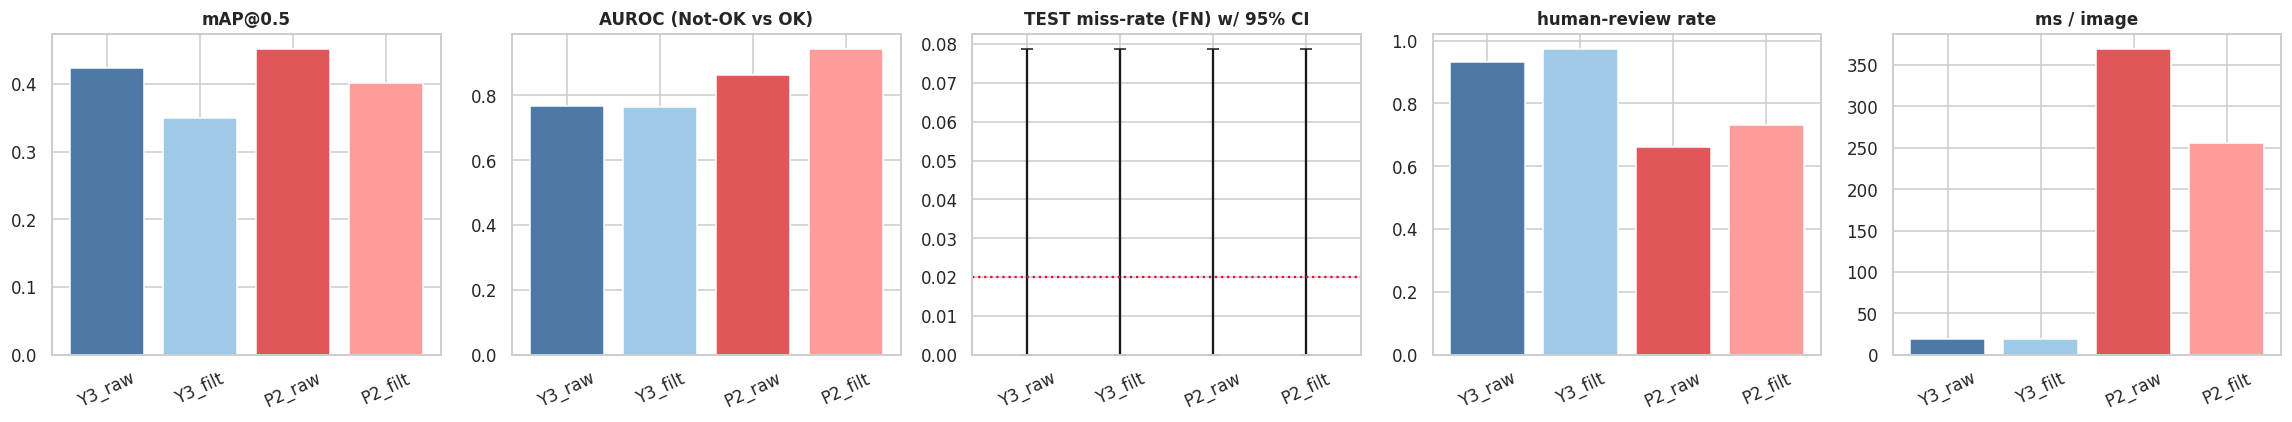

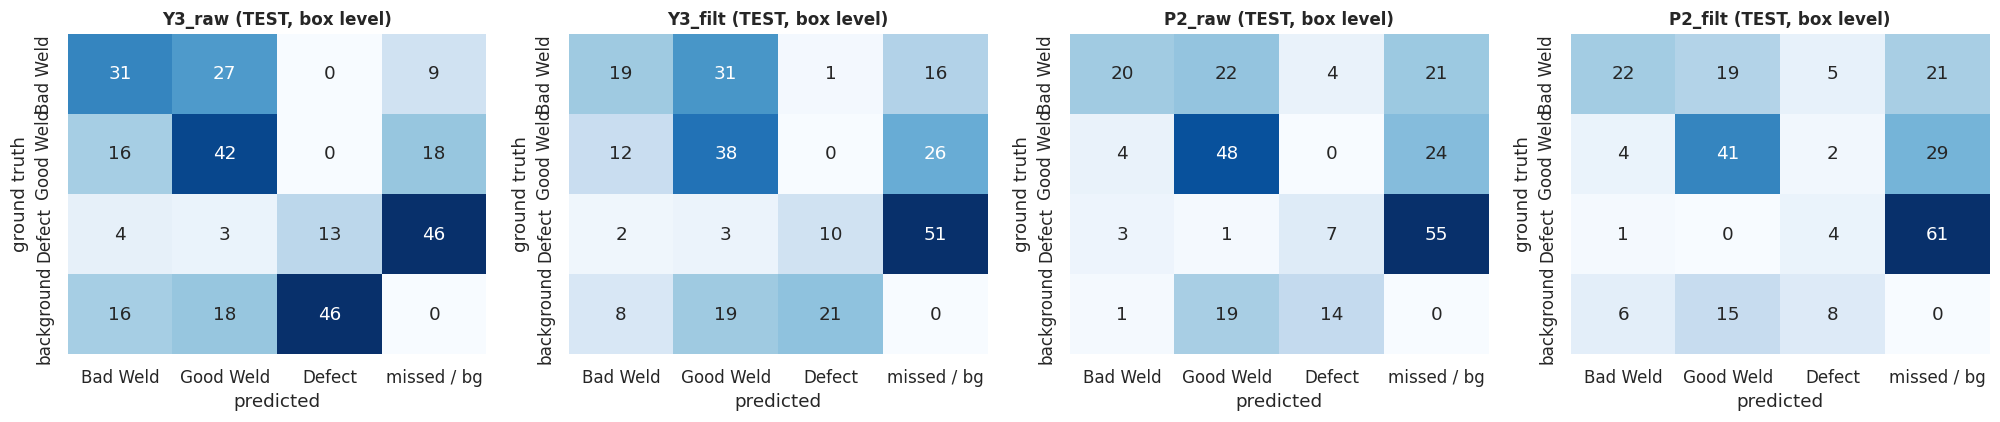

Best A=Y3_raw, best B=P2_raw
AUROC(B)-AUROC(A): mean +0.090  95% CI [-0.018, +0.205]
review-rate(B)-review-rate(A): mean -0.266  95% CI [-0.392, -0.149]
=> difference is NOT clearly significant (CI covers 0) - with 74 test images, prefer the simpler/faster system unless val says otherwise


In [25]:
cmp_ = TRI.query("split=='test'").set_index("pipe").join(EVAL.query("split=='test' and mode=='raw' and slice_type=='overall'").set_index("model_name")[["map50", "f1", "cls_acc", "ap_bad", "ap_good", "ap_defect"]])
cmp_["approach"] = ["A: YOLO 3-class" if p.startswith("Y3") else "B: YOLO-det + CNN" for p in cmp_.index]; cmp_["latency_ms"] = pd.Series(LAT)
val_rank = TRI.query("split=='valid'").set_index("pipe").assign(k=lambda d: d.review_rate - 1e-3 * d.auroc).k.sort_values()
SELECTED = val_rank.index[0]; print("val-selected system:", SELECTED, "\n", val_rank.round(3).to_dict())
cols = ["approach", "map50", "f1", "cls_acc", "ap_bad", "ap_good", "ap_defect", "auroc", "ece_raw", "ece_cal", "naive_FN_at_0_5", "fn", "n_notok", "miss_rate", "miss_lo", "miss_hi", "review_rate", "automation", "reject_precision", "latency_ms"]
from IPython.display import display
display(cmp_[cols].round(3))

fig, axs = plt.subplots(1, 5, figsize=(21, 4)); pal = ["#4e79a7", "#a0cbe8", "#e15759", "#ff9d9a"]; idx = list(PIPES)
for a, (k, t) in zip(axs, [("map50", "mAP@0.5"), ("auroc", "AUROC (Not-OK vs OK)"), ("miss_rate", "TEST miss-rate (FN) w/ 95% CI"), ("review_rate", "human-review rate"), ("latency_ms", "ms / image")]):
    a.bar(idx, cmp_.loc[idx, k], color=pal)
    if k == "miss_rate": a.errorbar(idx, cmp_.loc[idx, k], yerr=[cmp_.loc[idx, k] - cmp_.loc[idx, "miss_lo"], cmp_.loc[idx, "miss_hi"] - cmp_.loc[idx, k]], fmt="none", color="k", capsize=4); a.axhline(CFG["FN_TARGET"], color="crimson", ls=":")
    a.set_title(t); a.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

# box-level confusion matrices (test, raw) --------------------------------------------------------------------------------
fig, axs = plt.subplots(1, len(PIPES), figsize=(4.6 * len(PIPES), 4))
for a, pipe in zip(axs, PIPES):
    st = EV["test"]["raw"]; ent = {s: to_entries(PRED[pipe]["test"][s], TEMP[pipe]) for s in st}; cm = det_metrics(st, GT["test"]["raw"], ent)["confusion"]
    lab = CLASS_NAMES + ["missed / bg"]; sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=a, xticklabels=lab, yticklabels=CLASS_NAMES + ["background"]); a.set_title(f"{pipe} (TEST, box level)"); a.set_xlabel("predicted"); a.set_ylabel("ground truth")
plt.tight_layout(); plt.show()

# paired bootstrap on TEST: is B better than A? (AUROC and review-rate differences, best variant of each by val) ----------
bestA = val_rank[[p for p in val_rank.index if p.startswith("Y3")]].index[0]; bestB = val_rank[[p for p in val_rank.index if p.startswith("P2")]].index[0]
dA, dB = SC[bestA]["test"], SC[bestB]["test"]; assert (dA["stem"] == dB["stem"]).all(); rng = np.random.RandomState(0); diffs = []; rdiff = []
for _ in range(CFG["N_BOOT"] * 2):
    i = rng.randint(0, len(dA["y"]), len(dA["y"]))
    if len(set(dA["y"][i])) < 2: continue
    diffs.append(roc_auc_score(dB["y"][i], dB["cal"][i]) - roc_auc_score(dA["y"][i], dA["cal"][i])); rdiff.append((dB["verdict"][i] == "REVIEW").mean() - (dA["verdict"][i] == "REVIEW").mean())
print(f"Best A={bestA}, best B={bestB}\nAUROC(B)-AUROC(A): mean {np.mean(diffs):+.3f}  95% CI [{np.percentile(diffs, 2.5):+.3f}, {np.percentile(diffs, 97.5):+.3f}]"
      f"\nreview-rate(B)-review-rate(A): mean {np.mean(rdiff):+.3f}  95% CI [{np.percentile(rdiff, 2.5):+.3f}, {np.percentile(rdiff, 97.5):+.3f}]")
print("=> difference is", "NOT clearly significant (CI covers 0) - with 74 test images, prefer the simpler/faster system unless val says otherwise" if np.percentile(diffs, 2.5) < 0 < np.percentile(diffs, 97.5) else "statistically clear at 95%")

## 16. Human-review queue & failure gallery (selected system, test set)

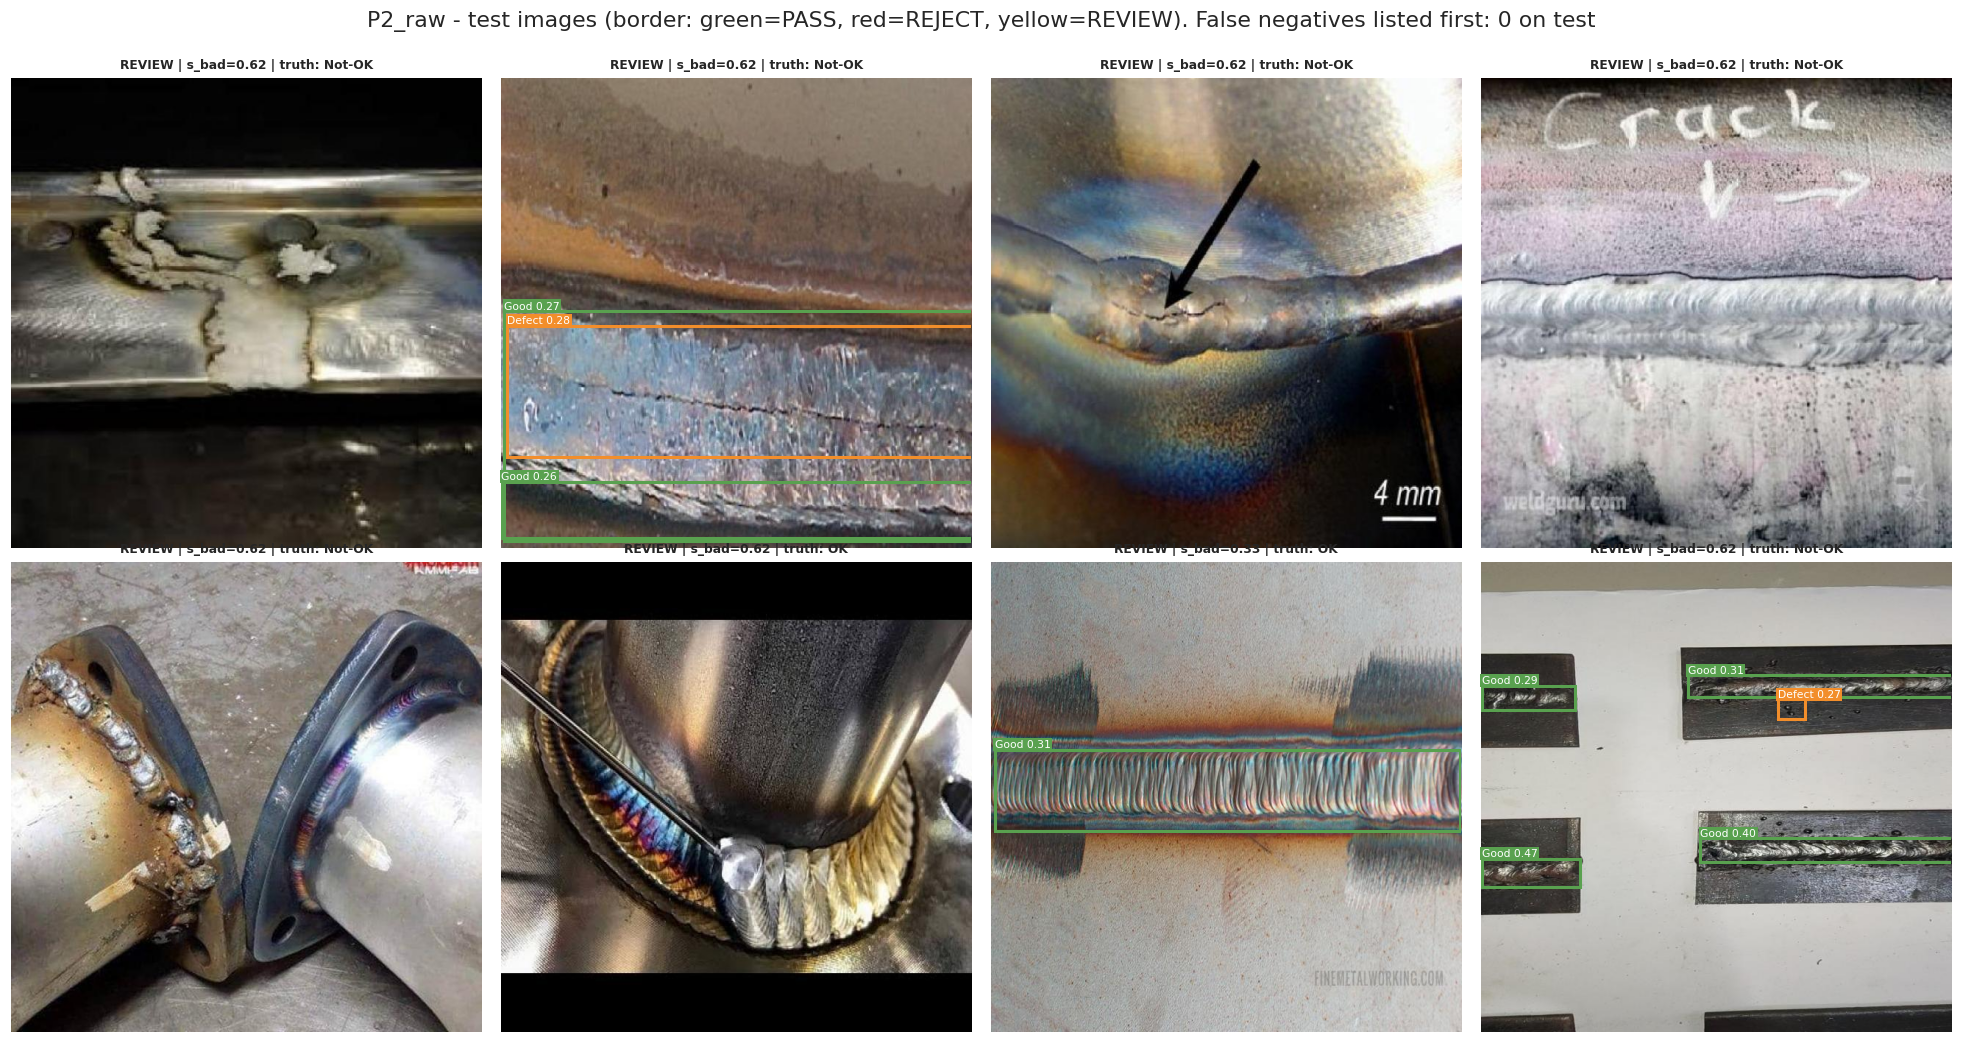

{'REVIEW': 49, 'REJECT': 13, 'PASS': 12} | FN on test: 0


In [26]:
def draw_pred(ax, pipe, sp, stem, title):
    P = PRED[pipe][sp][stem]; b, s, c = to_entries(P, TEMP[pipe]); k = agnostic_nms(b, s) if len(b) else np.array([], int); k = k[s[k] >= 0.25] if len(k) else k
    draw_boxes(ax, read_rgb(IMG_PATH[(sp, stem)]), b[k], c[k], title, texts=[f"{CLASS_NAMES[c[i]].split()[0]} {s[i]:.2f}" for i in k])
d = SC[SELECTED]["test"]; vcol = {"PASS": "#59a14f", "REJECT": "#e15759", "REVIEW": "#edc948"}
fn_idx = np.where((d["verdict"] == "PASS") & (d["y"] == 1))[0]; rv = np.where(d["verdict"] == "REVIEW")[0]; rest = np.where(d["verdict"] != "REVIEW")[0]
sel = list(fn_idx[:4]) + list(rv[:8 - len(fn_idx[:4])]); sel = (sel + list(rest))[:8]
fig, axs = plt.subplots(2, 4, figsize=(18, 9.5))
for a, i in zip(axs.ravel(), sel):
    truth = "Not-OK" if d["y"][i] else "OK"; tag = "  <-- FALSE NEGATIVE" if (d["verdict"][i] == "PASS" and d["y"][i]) else ""
    draw_pred(a, SELECTED, "test", d["stem"][i], f"{d['verdict'][i]} | s_bad={d['cal'][i]:.2f} | truth: {truth}{tag}")
    for sp_ in a.spines.values(): sp_.set_visible(True); sp_.set_edgecolor(vcol[d["verdict"][i]]); sp_.set_linewidth(5)
plt.suptitle(f"{SELECTED} - test images (border: green=PASS, red=REJECT, yellow=REVIEW). False negatives listed first: {len(fn_idx)} on test", y=1.0); plt.tight_layout(); plt.show()
print(pd.Series(d["verdict"]).value_counts().to_dict(), "| FN on test:", len(fn_idx))

## 17. Export & one-image inference helper

In [27]:
artefacts = dict(selected=SELECTED, policy=POL, temperature=TEMP, calibrators={k: v.kind for k, v in CAL.items()}, cfg={k: v for k, v in CFG.items() if k != "COUNT_BINS"}, hp=HP, class_names=CLASS_NAMES, bad_ids=list(BAD_IDS))
(WORK / "deployment_config.json").write_text(json.dumps(artefacts, indent=2, default=float)); pickle.dump(CAL, open(WORK / "calibrators.pkl", "wb"))
TRI.to_csv(WORK / "triage_summary_val_test.csv", index=False); LOG.save()

def inspect_image(path, pipe=None):
    pipe = pipe or SELECTED; P, _ = predict_paths(pipe, [path]); P = P[0]; sb, sa = image_scores(P, TEMP[pipe]); cs = float(CAL[pipe].transform(np.array([sb]))[0])
    v = str(apply_policy(np.array([cs]), np.array([sa]), POL[pipe])[0]); conf = {"PASS": 1 - cs, "REJECT": cs}.get(v, max(cs, 1 - cs))
    return dict(verdict=v, p_notok=round(cs, 3), verdict_confidence=round(conf, 3), sent_to_human=v == "REVIEW")
demo = [IMG_PATH[("test", s)] for s in EV["test"]["raw"][:3]]
for p in demo: print(Path(p).name[:40], "->", inspect_image(p))

lgdf = LOG.df(); print(f"\nLog: {LOG.path}  ({len(lgdf)} rows)\nrecord types:", lgdf.record_type.value_counts().to_dict(), "\nmodels:", sorted(lgdf.model_name.unique()))
print("columns:", list(lgdf.columns))
lgdf.query("record_type=='eval' and slice_type=='overall'")[["model_name", "component", "train_variant", "loss_fn", "split", "mode", "loss_total", "clf_ce", "map50", "f1"]].round(3).head(16)

02fd0af7-51ab46bb-c13_jpg.rf.7de08cd3b26 -> {'verdict': 'REVIEW', 'p_notok': 0.615, 'verdict_confidence': 0.615, 'sent_to_human': True}
1aa4b44c-d01b8a11-Hot-crack_jpg.rf.57393 -> {'verdict': 'REVIEW', 'p_notok': 0.623, 'verdict_confidence': 0.623, 'sent_to_human': True}
295992d6-f617b725-c1_png_jpg.rf.5f645e13 -> {'verdict': 'REVIEW', 'p_notok': 0.615, 'verdict_confidence': 0.615, 'sent_to_human': True}

Log: weld_work/experiment_log.csv  (420 rows)
record types: {'epoch': 290, 'eval': 120, 'calibration': 6, 'policy': 4} 
models: ['CNN_filt', 'CNN_raw', 'DET_filt', 'DET_raw', 'P2_filt', 'P2_raw', 'Y3_filt', 'Y3_raw']
columns: ['timestamp', 'run_id', 'record_type', 'model_name', 'approach', 'component', 'train_variant', 'loss_fn', 'arch', 'epoch', 'split', 'mode', 'slice_type', 'slice_value', 'n_images', 'n_boxes', 'seed', 'area_thr', 'max_boxes', 'quick_mode', 'device', 'torch', 'ultralytics', 'python', 'imgsz', 'epochs_planned', 'n_train_images', 'n_train_boxes', 'train_box', 'train_

,model_name,component,train_variant,loss_fn,split,mode,loss_total,clf_ce,map50,f1
290,Y3_raw,pipeline,raw,focal(g=1.5)+cw,valid,raw,14.440,NaN,0.478,0.472
298,Y3_raw,pipeline,raw,focal(g=1.5)+cw,valid,filt,15.265,NaN,0.438,0.450
304,Y3_raw,pipeline,raw,focal(g=1.5)+cw,test,raw,17.810,NaN,0.423,0.405
312,Y3_raw,pipeline,raw,focal(g=1.5)+cw,test,filt,17.129,NaN,0.378,0.381
318,Y3_filt,pipeline,filt,focal(g=1.5)+cw,valid,raw,14.643,NaN,0.414,0.458
326,Y3_filt,pipeline,filt,focal(g=1.5)+cw,valid,filt,15.405,NaN,0.411,0.443
332,Y3_filt,pipeline,filt,focal(g=1.5)+cw,test,raw,17.297,NaN,0.350,0.359
340,Y3_filt,pipeline,filt,focal(g=1.5)+cw,test,filt,17.324,NaN,0.352,0.371
346,P2_raw,pipeline,raw,focal(g=1.5)+cw | focal(g=2.0)+cw,valid,raw,11.161,0.530,0.494,0.511
354,P2_raw,pipeline,raw,focal(g=1.5)+cw | focal(g=2.0)+cw,valid,filt,11.895,0.504,0.465,0.479
